## Preprocessing NKI Rockland ET Data 

In [1]:
from pynwb import NWBHDF5IO
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import seaborn as sns
import numpy as np 
import os
from scipy.stats import pearsonr
from scipy.stats import gaussian_kde
import cv2
from scipy.signal import butter, filtfilt
from scipy.signal import savgol_filter

from scipy.ndimage import gaussian_filter
from pathlib import Path

# Set working directory to test this out locally 
os.chdir('/Users/nicole.burke/OneDrive - Child Mind Institute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data')
print(os.getcwd())

### Custom functions for script 
def descr_stats(df, column_name):
    stats = df[column_name].agg(
        mean='mean',
        min='min',
        max='max',
        std='std'
    )
    print(f"Summary stats for column: {column_name}")
    print(stats)

    return stats

/Users/nicole.burke/Library/CloudStorage/OneDrive-ChildMindInstitute/02_Projects/06_rockland_sample/01_rockland_descriptor_paper/complied_server_data


## *The Present* DS1 Preprocesssing

In [ ]:
present_df1 = pd.read_csv("present_df_all_raw.csv")
print(present_df1.head())
present_df1 = present_df1.iloc[:, 1:]
print(present_df1.head())

# Sort by subjectID and time 
present_df1 = present_df1.sort_values(['subjectID', 'times'])
print(present_df1.head(-20))

### Exclude subjects with large difference in time gap 


In [ ]:
for subj, grp in present_df1.groupby("subjectID"):

    grp = grp.sort_values("times").copy()
    grp["dt"] = grp["times"].diff()

    big_gaps = grp[grp["dt"] > 1]

    if len(big_gaps):
        print(f"\nSubject {subj}")
        print(big_gaps[["times", "dt"]])

In [ ]:
excluded_subjs = [
    'sub-A00057372',
    'sub-A00086551'
]

present_df1 = present_df1[
    ~present_df1["subjectID"].isin(excluded_subjs)
].copy()

Check that excluded subjects are excluded 


In [ ]:
for subj, grp in present_df1.groupby("subjectID"):

    grp = grp.sort_values("times").copy()
    grp["dt"] = grp["times"].diff()

    big_gaps = grp[grp["dt"] > 1]

    if len(big_gaps):
        print(f"\nSubject {subj}")
        print(big_gaps[["times", "dt"]])

### Descriptive Stats 

In [ ]:
descr_stats(present_df1, 'x_corr_pixels')
descr_stats(present_df1, 'y_corr_pixels')
descr_stats(present_df1, 'left_eye_pupil_mm')
descr_stats(present_df1, 'right_eye_pupil_mm')

# check missing values 
print("missing values x_corr:", present_df1['x_corr_pixels'].isna().sum()) 
print("missing values y_corr:", present_df1['y_corr_pixels'].isna().sum())
print("missing values left_eye_pupil:", present_df1['left_eye_pupil_mm'].isna().sum())
print("missing values right_eye_pupil:", present_df1['right_eye_pupil_mm'].isna().sum())

# plot histograms 
plt.figure(figsize=(10, 5))
present_df1["x_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
present_df1["y_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

plt.figure(figsize=(10, 5))
present_df1["left_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("left_eye_pupil_mm histogram")

plt.figure(figsize=(10, 5))
present_df1["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

### 1. Clean Data: clip to screen dimension for x_corr and y_corr and recode extreme values of pupil diameter to 0 


#### 1a: Clip x_corr and y_corr to the screen dimensions 

Values outside the dimension of our screen get recoded to their the lower or upper bound

In [ ]:
present_df1_filtered = present_df1.copy()

SCREEN_W = 1920
SCREEN_H = 1080

present_df1_filtered["x_corr_pixels"] = present_df1["x_corr_pixels"].clip(0, SCREEN_W)
present_df1_filtered["y_corr_pixels"] = present_df1["y_corr_pixels"].clip(0, SCREEN_H)

# Look at data again 
descr_stats(present_df1_filtered, 'x_corr_pixels')
descr_stats(present_df1_filtered, 'y_corr_pixels')

# plot histograms 
plt.figure(figsize=(10, 5))
present_df1_filtered["x_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
present_df1_filtered["y_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

#### 1b: Recode extreme values of pupil diameter to 0
To run the blink detection algothrim, it needs 0 values, not NA. 


In [ ]:
# largest possible pupil value 
max_pupil_diameter = 9

# filter out data 
present_df1_filtered['left_eye_pupil_mm'] = present_df1_filtered["left_eye_pupil_mm"].where(
    present_df1_filtered['left_eye_pupil_mm'] <= max_pupil_diameter, 0
)
present_df1_filtered['right_eye_pupil_mm'] = present_df1_filtered["right_eye_pupil_mm"].where(
    present_df1_filtered['right_eye_pupil_mm'] <= max_pupil_diameter, 0
)

# re-check data 
descr_stats(present_df1_filtered, 'left_eye_pupil_mm')
descr_stats(present_df1_filtered, 'right_eye_pupil_mm')
plt.figure(figsize=(10, 5))
present_df1_filtered["left_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("left_eye_pupil_mm histogram")

plt.figure(figsize=(10, 5))
present_df1_filtered["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

### 2. Blink Detection - Hershman et al. 2018 - REDO

Using open source code from Hershman et al. 2018: https://osf.io/jyz43/files/qh5sg

In [ ]:
def diff(series):
	"""
	Python implementation of matlab's diff function
	"""
	return series[1:] - series[:-1]

def smooth(x, window_len):
	"""
	Python implementation of matlab's smooth function
	"""

	if window_len < 3:
		return x

	# Window length must be odd
	if window_len%2 == 0:
		window_len += 1

	w = np.ones(window_len)
	y = np.convolve(w, x, mode='valid') / len(w)
	y = np.hstack((x[:window_len//2], y, x[len(x)-window_len//2:]))

	for i in range(0, window_len//2):
		y[i] = np.sum(y[0 : i+i]) / ((2*i) + 1)

	for i in range(len(x)-window_len//2, len(x)):
		y[i] = np.sum(y[i - (len(x) - i - 1) : i + (len(x) - i - 1)]) / ((2*(len(x) - i - 1)) + 1)

	return y

def based_noise_blinks_detection(pupil_size, sampling_freq):
	"""
	Function to find blinks and return blink onset and offset indices
	Adapted from: R. Hershman, A. Henik, and N. Cohen, “A novel blink detection method based on pupillometry noise,” Behav. Res. Methods, vol. 50, no. 1, pp. 107–114, 2018.

	Input:
		pupil_size          : [numpy array/list] of pupil size data for left/right eye
		sampling_freq       : [float] sampling frequency of eye tracking hardware (default = 1000 Hz)
		concat              : [boolean] concatenate close blinks/missing trials or not. See R. Hershman et. al. for more information
		concat_gap_interval : [float] interval between successive missing samples/blinks to concatenate
	Output:
		blinks              : [dictionary] {"blink_onset", "blink_offset"} containing numpy array/list of blink onset and offset indices
	"""
	sampling_interval = 1000 // sampling_freq
	concat_gap_interval = 100

	blink_onset = []
	blink_offset = []
	blinks = {"blink_onset": blink_onset, "blink_offset": blink_offset}

	pupil_size = np.asarray(pupil_size)
	missing_data = np.array(pupil_size == 0, dtype="float32")
	difference = diff(missing_data)

	blink_onset = np.where(difference == 1)[0]
	blink_offset = np.where(difference == -1)[0] + 1

	length_blinks = len(blink_offset) + len(blink_onset)


	# Edge Case 1: there are no blinks
	if (length_blinks == 0):
		return blinks


	# Edge Case 2: the data starts with a blink. In this case, blink onset will be defined as the first missing value.
	"""
		Two possible situations may cause this:
			i.  starts with a blink but does not end with a blink ---> len(blink_onset) < len(blink_offset)
			ii. starts with a blink and ends with a blink		  ---> len(blink_onset) == len(blink_offset) and (blink_onset[0] == blink_offset[0])
	"""
	if ((len(blink_onset) < len(blink_offset)) or ((len(blink_onset) == len(blink_offset)) and (blink_onset[0] > blink_offset[0]))) and pupil_size[0] == 0:
		blink_onset = np.hstack((0, blink_onset))


	# Edge Case 3: the data ends with a blink. In this case, blink offset will be defined as the last missing sample
	"""
		Two possible situations may cause this:
			i.  ends with a blink but does not start with a blink ---> len(blink_offset) < len(blink_onset)
			ii. ends with a blink and starts with a blink		  ---> Already handled "start with blink" in Edge case 2 so it reduces to i (previous case)
	"""
	if (len(blink_offset) < len(blink_onset)) and pupil_size[-1] == 0:
		blink_offset = np.hstack((blink_offset, len(pupil_size) - 1))

	# Smoothing the data in order to increase the difference between the measurement noise and the eyelid signal.
	ms_4_smoothing = 10
	samples2smooth = ms_4_smoothing // sampling_interval
	smooth_pupil_size = np.array(smooth(pupil_size, samples2smooth), dtype='float32')

	smooth_pupil_size[np.where(smooth_pupil_size == 0)[0]] = float('nan')
	smooth_pupil_size_diff = diff(smooth_pupil_size)

	"""
	Finding values <=0 and >=0 in order to find monotonically increasing and decreasing sections of smoothened pupil data

			Eg. a =     [2, 1, 2, 8, 7, 6, 5, 4, 4, 0, 0, 0, 0, 0, 3, 3, 3, 8, 9, 10, 2, 3, 10]
	                              ----------------  S           E  =================
			diff(a)=   [-1  1  6 -1 -1 -1 -1  0 -4  0  0  0  0  3  0  0  5  1  1  -8  1  7]

	monotonically_dec = [T  F  F  T  T  T  T  T  T  T  T  T  T  F  T  T  F  F  F   T  F  F]   (T=True, F=False)
	monotonically_dec = [F  T  T  F  F  F  F  T  F  T  T  T  T  T  T  T  T  T  T   F  T  T]

	---> The monotonically decreasing sequence before the blink is underlined with -- and the monotonically increasing sequence after the blink with ==
	---> S : denotes the initially detected onset of blink
	---> E : denotes the initially detected offset of blink

	>> Looking at diff(a), all values in the montonically decreasing sequence should be <= 0 and those included in the monotonically increasing sequence >= 0
	>> Hence, by moving left from the initially detected onset while T(True) values are encountered in monotonically_dec we can update the onset to the start of monotonically_dec seq
	>> By moving right from the initially detected offset while T(True) values are encountered in monotonically_inc we can update the offset to the end of monotonically_inc seq + 1
	"""
	monotonically_dec = smooth_pupil_size_diff <= 0
	monotonically_inc = smooth_pupil_size_diff >= 0

	# Finding correct blink onsets and offsets using monotonically increasing and decreasing arrays
	for i in range(len(blink_onset)):
		# Edge Case 2: If data starts with blink we do not update it and let starting blink index be 0
		if blink_onset[i] != 0:
			j = blink_onset[i] - 1
			while j > 0 and monotonically_dec[j] == True:
				j -= 1
			blink_onset[i] = j + 1

		# Edge Case 3: If data ends with blink we do not update it and let ending blink index be the last index of the data
		if blink_offset[i] != len(pupil_size) - 1:
			j = blink_offset[i]
			while j < len(monotonically_inc) and monotonically_inc[j] == True:
				j += 1
			blink_offset[i] = j

	# Removing duplications (in case of consecutive sets): [a, b, b, c] => [a, c] or if inter blink interval is less than concat_gap_interval
	c = np.empty((len(blink_onset) + len(blink_offset),), dtype=blink_onset.dtype)
	c[0::2] = blink_onset
	c[1::2] = blink_offset
	c = list(c)

	i = 1
	while i<len(c)-1:
		if c[i+1] - c[i] <= concat_gap_interval:
			c[i:i+2] = []
		else:
			i += 2

	temp = np.reshape(c, (-1, 2), order='C')

	"""
	Multplied by sampling interval in order to give onset and offset in real time (milliseconds) by factoring in sampling rate of device used
	'+ sampling_interval' because the output should be in real time and as python indexing starts at 0 instead of 1, this is the standardising factor
	NOTE:edit the lines below to only temp[:, 0] and temp[:, 1] in case you are interested in the indices of blinks and not realtime values
	"""
	blinks["blink_onset"] = (temp[:, 0] * sampling_interval) + sampling_interval
	blinks["blink_offset"] = (temp[:, 1] * sampling_interval) + sampling_interval

	return blinks

Confirm sampling rate 

In [ ]:
# Calculate time difference between consecutive samples 
present_df1_filtered['time_diff'] = present_df1_filtered.groupby('subjectID')['times'].diff()

# Calculate sampling rate (Hz)
present_df1_filtered['sampling_rate'] = 1 / present_df1_filtered['time_diff']

descr_stats(present_df1_filtered, 'sampling_rate')

Detect blinks - make sure this works 

In [ ]:
sampling_freq = 180
blinks = based_noise_blinks_detection(present_df1_filtered['right_eye_pupil_mm'], sampling_freq)
print(blinks)

Mask blinks - function to run blink detection algothrim on whole sample 

In [ ]:
BLINK_BUFFER_MS = 50  # buffer 50 ms before and after blink

def mask_blinks(df, sample_rate, buffer_ms=BLINK_BUFFER_MS):
    """
    Detect blinks using Hershman et al. (2018) and set gaze to NaN
    during blink periods + buffer window around each blink.
    Requires a pupil diameter column (0 = missing/blink).
    """
    df = df.sort_values(["subjectID", "times"]).reset_index(drop=True)

    print("column names:", df.columns)

    df[["x_corr_pixels", "y_corr_pixels"]] = (
        df[["x_corr_pixels", "y_corr_pixels"]].astype(float)
    )

    total_blinks = 0

    for subj, grp in df.groupby("subjectID"):

        idx = grp.index

        # Algorithm expects missing pupil values to be 0
        pupil = grp["right_eye_pupil_mm"].fillna(0).to_numpy().copy()
        pupil[pupil < 0] = 0

        # Detect blinks for THIS SUBJECT ONLY
        blinks = based_noise_blinks_detection(
            pupil,
            sampling_freq=sample_rate,
        )

        n_blinks = len(blinks["blink_onset"])
        total_blinks += n_blinks

        if n_blinks == 0:
            continue

        # Subject's timestamps (seconds -> milliseconds)
        times_ms = grp["times"].to_numpy() * 1000

        for onset_ms, offset_ms in zip(
            blinks["blink_onset"],
            blinks["blink_offset"],
        ):

            blink_mask = (
                (times_ms >= onset_ms - buffer_ms)
                & (times_ms <= offset_ms + buffer_ms)
            )

            df.loc[
                idx[blink_mask],
                ["x_corr_pixels", "y_corr_pixels"],
            ] = np.nan

    print(
        f"[Step 2] Total blinks detected: {total_blinks} across "
        f"{df['subjectID'].nunique()} subjects"
    )

    print(
        f"         NaN gaze samples after masking: "
        f"{df['x_corr_pixels'].isna().sum()} "
        f"({df['x_corr_pixels'].isna().mean() * 100:.2f}%)"
    )

    return df

Apply blink detection 

In [ ]:
# Make a copy of the dataframe 
present_df1_mask = present_df1_filtered.copy()

# Apply blink detection filter 
present_df1_mask = mask_blinks(present_df1_mask, sample_rate=180)

Re-plot data to see what it looks like

In [ ]:
# plot histograms 
plt.figure(figsize=(10, 5))
present_df1_mask["x_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
present_df1_mask["y_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

plt.figure(figsize=(10, 5))
present_df1_mask["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

### 3. Butterworth Low Pass Filter

In [ ]:
# documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html
sampling_rate = 180 
cutoff_freq = 50
filter_order = 2    

def butter_lowpass_filter(data, cutoff, fs, order=2):
    nyq = 0.5 * fs # Nyquist frequency; recommended from documentation 
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients
    #   Using order 2, nyquist freq, lowpass filter, and for digital signal
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # Apply filter forwards and backwards to eliminate phase distortion
    y = filtfilt(b, a, data)
    return y

# Make copy of dataframe 
present_df1_butter = present_df1_mask.copy()

# Apply the low pass filter
present_df1_butter['x_corr_pixels_butter'] = butter_lowpass_filter(present_df1_butter['x_corr_pixels'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)
present_df1_butter['y_corr_pixels_butter'] = butter_lowpass_filter(present_df1_butter['y_corr_pixels'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)

Re-plot to see what data looks like

In [ ]:
# plot histograms 
plt.figure(figsize=(10, 5))
present_df1_butter["x_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
present_df1_butter["y_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

plt.figure(figsize=(10, 5))
present_df1_butter["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

Show filtered vs. unfiltered data 

In [ ]:
############ x
########### UNFILTERED, POST BLINK

fig, ax = plt.subplots(figsize=(12, 4))

for subject, df in present_df1_mask.groupby("subjectID"):
    df = df.sort_values("times")
    ax.plot(
        df["times"],
        df["x_corr_pixels"],
        linewidth=1,
        color="#2563eb",
        alpha=0.5,
    )

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("x corr pixels", fontsize=12)
ax.set_title("Tracker 1 (180 Hz): Raw Data X, Unfiltered, Post Blink Detection", fontsize=14)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


############ FILTERED

fig, ax = plt.subplots(figsize=(12, 4))

for subject, df in present_df1_butter.groupby("subjectID"):
    df = df.sort_values("times")
    ax.plot(
        df["times"],
        df["x_corr_pixels_butter"],
        linewidth=1,
        color="#eb2525",
        alpha=0.5,
    )

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("x_corr_pixels_butter", fontsize=12)
ax.set_title("Tracker 1 (180 Hz): Filtered Data X", fontsize=14)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

Get subset of subjects to plot 

In [ ]:
subset_subjects = present_df1_mask['subjectID'].unique()[0:5]
print(subset_subjects)


present_df1_mask_subset = present_df1_mask[present_df1_mask['subjectID'].isin(subset_subjects)]
print("length of present_df1_mask:", len(present_df1_mask))
print("length of present_df1_mask_subset:", len(present_df1_mask_subset))

present_df1_butter_subset = present_df1_butter[present_df1_butter['subjectID'].isin(subset_subjects)]
print("length of present_df1_butter:", len(present_df1_butter))
print("length of present_df1_butter_subset:", len(present_df1_butter_subset))

In [ ]:
subjects = sorted(present_df1_mask_subset["subjectID"].unique())

for subject in subjects:
    raw = present_df1_mask_subset[
        present_df1_mask_subset["subjectID"] == subject
    ]
    filt = present_df1_butter_subset[
        present_df1_butter_subset["subjectID"] == subject
    ]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # Raw
    axes[0].plot(
        raw["times"],
        raw["x_corr_pixels"],
        color="#2563eb",
        linewidth=1,
    )
    axes[0].set_title(f"Subject {subject}: Raw X (Post Blink Detection)")
    axes[0].set_ylabel("x_corr_pixels")
    axes[0].grid(alpha=0.3, linestyle="--")

    # Filtered
    axes[1].plot(
        filt["times"],
        filt["x_corr_pixels_butter"],
        color="#eb2525",
        linewidth=1,
    )
    axes[1].set_title(f"Subject {subject}: Butterworth Filtered X")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("x_corr_pixels_butter")
    axes[1].grid(alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

### 4. Standarized Data (min-max filter)

In [ ]:
# Make copy of dataframe 
present_df1_norm = present_df1_butter.copy()

# x_corr_pixels_butter 
x_min_present_ds1 = present_df1_norm['x_corr_pixels_butter'].min()
x_max_present_ds1 = present_df1_norm['x_corr_pixels_butter'].max()
present_df1_norm['x_norm'] = (present_df1_norm['x_corr_pixels_butter'] - x_min_present_ds1) / (x_max_present_ds1 - x_min_present_ds1)
descr_stats(present_df1_norm, 'x_norm')

# y_corr_pixels_butter 
y_min_present_ds1 = present_df1_norm['y_corr_pixels_butter'].min()
y_max_present_ds1 = present_df1_norm['y_corr_pixels_butter'].max()
present_df1_norm['y_norm'] = (present_df1_norm['y_corr_pixels_butter'] - y_min_present_ds1) / (y_max_present_ds1 - y_min_present_ds1)
descr_stats(present_df1_norm, 'y_norm')

### 5. Computer Euclidean Distance

In [ ]:
# Sort data by time per subject (to get time diference)
present_df1_norm = present_df1_norm.sort_values(by=["subjectID", "times"]).reset_index(drop=True)

# Calculate the difference (x2 - x1) and (y2 - y1) per subject 
present_df1_norm["diff_x"] = present_df1_norm.groupby("subjectID")["x_norm"].diff()
present_df1_norm["diff_y"] = present_df1_norm.groupby("subjectID")["y_norm"].diff()

# Calculate Eucledian Distance: z = sqrt((x2-x1)^2 + (y2-y1)^2)
present_df1_norm["z_eucledian_dist"] = np.sqrt(present_df1_norm["diff_x"] ** 2 + present_df1_norm['diff_y'] ** 2)

# Check Eucledian Distance 
print(descr_stats(present_df1_norm, 'z_eucledian_dist'))

In [ ]:
#### Current number of samples
print("Current number of samples:", len(present_df1_norm))

# Filter out extreme values of Eucledian Distance 
z_eucledian_dist_mean = present_df1_norm['z_eucledian_dist'].mean()
z_eucledian_dist_std = present_df1_norm['z_eucledian_dist'].std()
upper_z_eucled = z_eucledian_dist_mean + (2.5*z_eucledian_dist_std)
lower_z_eucled = z_eucledian_dist_mean - (2.5*z_eucledian_dist_std)
print(upper_z_eucled)
print("Z EUCLEDIAN DISTANCE BEFORE")
print(f"mean: {z_eucledian_dist_mean}; min: {present_df1_norm['z_eucledian_dist'].min()}; max: {present_df1_norm['z_eucledian_dist'].max()}") 

# filter 
present_df1_norm = present_df1_norm[present_df1_norm['z_eucledian_dist'] >= lower_z_eucled]
present_df1_norm = present_df1_norm[present_df1_norm['z_eucledian_dist'] <= upper_z_eucled]

print("*"*50)
print("Z EUCLEDIAN DISTANCE after filter")
print(f"mean: {present_df1_norm['z_eucledian_dist'].mean()}; min: {present_df1_norm['z_eucledian_dist'].min()}; max: {present_df1_norm['z_eucledian_dist'].max()}")
print("New samples:", len(present_df1_norm))


### 6. Compute ISC 

In [ ]:
df = present_df1_norm.copy()

# --- Interpolate onto time grid (same as before) ---
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['x_corr_pixels_butter']))
    y_mat.append(np.interp(time_grid, d['times'], d['y_corr_pixels_butter']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_ds1_present = pd.DataFrame(isc_results)
isc_ds1_present['rank_x'] = isc_ds1_present['ISC_x'].rank()
isc_ds1_present['rank_y'] = isc_ds1_present['ISC_y'].rank()
isc_ds1_present['rank_mean'] = isc_ds1_present['ISC_mean'].rank()
print(isc_ds1_present.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

Combine ISC data with dataframe 

In [ ]:
df = present_df1_norm.merge(isc_ds1_present[['subjectID', 'ISC_mean', "rank_mean"]], on="subjectID")
print(df.head())

### 7. PLOT

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_mean"],
    C=df["z_eucledian_dist"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Z Eucledian Distance", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_y"].min(),
#                          df["rank_y"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis 
plt.xlim(0,210)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("Present Tracker 1 (180hz): Z Eucledian Distance Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## *Sherlock* DS1 Preprocesssing

In [ ]:
sherlock_df1 = pd.read_csv("sherlock_df_all_raw.csv")
print(sherlock_df1.head())
sherlock_df1 = sherlock_df1.iloc[:, 1:]
print(sherlock_df1.head())

# Sort by subjectID and time 
sherlock_df1 = sherlock_df1.sort_values(['subjectID', 'times'])
print(sherlock_df1.head(-20))

### Exclude subjects with large difference in time gap 

In [ ]:
for subj, grp in sherlock_df1.groupby("subjectID"):

    grp = grp.sort_values("times").copy()
    grp["dt"] = grp["times"].diff()

    big_gaps = grp[grp["dt"] > 1]

    if len(big_gaps):
        print(f"\nSubject {subj}")
        print(big_gaps[["times", "dt"]])

In [ ]:
excluded_subjs = [
    'sub-A00023214',
    'sub-A00050812',
    'sub-A00074113',
    'sub-A00077204',
    'sub-A00081734'
]

sherlock_df1 = sherlock_df1[
    ~sherlock_df1["subjectID"].isin(excluded_subjs)
].copy()

Check that excluded subjects are excluded 

In [ ]:
for subj, grp in sherlock_df1.groupby("subjectID"):

    grp = grp.sort_values("times").copy()
    grp["dt"] = grp["times"].diff()

    big_gaps = grp[grp["dt"] > 1]

    if len(big_gaps):
        print(f"\nSubject {subj}")
        print(big_gaps[["times", "dt"]])

### Descriptive Stats 

In [ ]:
descr_stats(sherlock_df1, 'x_corr_pixels')
descr_stats(sherlock_df1, 'y_corr_pixels')
descr_stats(sherlock_df1, 'left_eye_pupil_mm')
descr_stats(sherlock_df1, 'right_eye_pupil_mm')

# check missing values 
print("missing values x_corr:", sherlock_df1['x_corr_pixels'].isna().sum()) 
print("missing values y_corr:", sherlock_df1['y_corr_pixels'].isna().sum())
print("missing values left_eye_pupil:", sherlock_df1['left_eye_pupil_mm'].isna().sum())
print("missing values right_eye_pupil:", sherlock_df1['right_eye_pupil_mm'].isna().sum())

# plot histograms 
plt.figure(figsize=(10, 5))
sherlock_df1["x_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
sherlock_df1["y_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

plt.figure(figsize=(10, 5))
sherlock_df1["left_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("left_eye_pupil_mm histogram")

plt.figure(figsize=(10, 5))
sherlock_df1["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

plt.figure(figsize=(10, 5))
sherlock_df1["times"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("times")


### 1. Clean Data: clip to screen dimension for x_corr and y_corr and recode extreme values of pupil diameter to 0 


#### 1a: Clip x_corr and y_corr to the screen dimensions 

Values outside the dimension of our screen get recoded to their the lower or upper bound


In [ ]:
sherlock_df1_filtered = sherlock_df1.copy()

SCREEN_W = 1920
SCREEN_H = 1080

sherlock_df1_filtered["x_corr_pixels"] = sherlock_df1["x_corr_pixels"].clip(0, SCREEN_W)
sherlock_df1_filtered["y_corr_pixels"] = sherlock_df1["y_corr_pixels"].clip(0, SCREEN_H)

# Look at data again 
descr_stats(sherlock_df1_filtered, 'x_corr_pixels')
descr_stats(sherlock_df1_filtered, 'y_corr_pixels')

# plot histograms 
plt.figure(figsize=(10, 5))
sherlock_df1_filtered["x_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
sherlock_df1_filtered["y_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

#### 1b: Recode extreme values of pupil diameter to 0
To run the blink detection algothrim, it needs 0 values, not NA. 


In [ ]:
# largest possible pupil value 
max_pupil_diameter = 9

# filter out data 
sherlock_df1_filtered['left_eye_pupil_mm'] = sherlock_df1_filtered["left_eye_pupil_mm"].where(
    sherlock_df1_filtered['left_eye_pupil_mm'] <= max_pupil_diameter, 0
)
sherlock_df1_filtered['right_eye_pupil_mm'] = sherlock_df1_filtered["right_eye_pupil_mm"].where(
    sherlock_df1_filtered['right_eye_pupil_mm'] <= max_pupil_diameter, 0
)

# re-check data 
descr_stats(sherlock_df1_filtered, 'left_eye_pupil_mm')
descr_stats(sherlock_df1_filtered, 'right_eye_pupil_mm')
plt.figure(figsize=(10, 5))
sherlock_df1_filtered["left_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("left_eye_pupil_mm histogram")

plt.figure(figsize=(10, 5))
sherlock_df1_filtered["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

### 2. Blink Detection - Hershman et al. 2018

Using open source code from Hershman et al. 2018: https://osf.io/jyz43/files/qh5sg


In [ ]:
def diff(series):
	"""
	Python implementation of matlab's diff function
	"""
	return series[1:] - series[:-1]

def smooth(x, window_len):
	"""
	Python implementation of matlab's smooth function
	"""

	if window_len < 3:
		return x

	# Window length must be odd
	if window_len%2 == 0:
		window_len += 1

	w = np.ones(window_len)
	y = np.convolve(w, x, mode='valid') / len(w)
	y = np.hstack((x[:window_len//2], y, x[len(x)-window_len//2:]))

	for i in range(0, window_len//2):
		y[i] = np.sum(y[0 : i+i]) / ((2*i) + 1)

	for i in range(len(x)-window_len//2, len(x)):
		y[i] = np.sum(y[i - (len(x) - i - 1) : i + (len(x) - i - 1)]) / ((2*(len(x) - i - 1)) + 1)

	return y

def based_noise_blinks_detection(pupil_size, sampling_freq):
	"""
	Function to find blinks and return blink onset and offset indices
	Adapted from: R. Hershman, A. Henik, and N. Cohen, “A novel blink detection method based on pupillometry noise,” Behav. Res. Methods, vol. 50, no. 1, pp. 107–114, 2018.

	Input:
		pupil_size          : [numpy array/list] of pupil size data for left/right eye
		sampling_freq       : [float] sampling frequency of eye tracking hardware (default = 1000 Hz)
		concat              : [boolean] concatenate close blinks/missing trials or not. See R. Hershman et. al. for more information
		concat_gap_interval : [float] interval between successive missing samples/blinks to concatenate
	Output:
		blinks              : [dictionary] {"blink_onset", "blink_offset"} containing numpy array/list of blink onset and offset indices
	"""
	sampling_interval = 1000 // sampling_freq
	concat_gap_interval = 100

	blink_onset = []
	blink_offset = []
	blinks = {"blink_onset": blink_onset, "blink_offset": blink_offset}

	pupil_size = np.asarray(pupil_size)
	missing_data = np.array(pupil_size == 0, dtype="float32")
	difference = diff(missing_data)

	blink_onset = np.where(difference == 1)[0]
	blink_offset = np.where(difference == -1)[0] + 1

	length_blinks = len(blink_offset) + len(blink_onset)


	# Edge Case 1: there are no blinks
	if (length_blinks == 0):
		return blinks


	# Edge Case 2: the data starts with a blink. In this case, blink onset will be defined as the first missing value.
	"""
		Two possible situations may cause this:
			i.  starts with a blink but does not end with a blink ---> len(blink_onset) < len(blink_offset)
			ii. starts with a blink and ends with a blink		  ---> len(blink_onset) == len(blink_offset) and (blink_onset[0] == blink_offset[0])
	"""
	if ((len(blink_onset) < len(blink_offset)) or ((len(blink_onset) == len(blink_offset)) and (blink_onset[0] > blink_offset[0]))) and pupil_size[0] == 0:
		blink_onset = np.hstack((0, blink_onset))


	# Edge Case 3: the data ends with a blink. In this case, blink offset will be defined as the last missing sample
	"""
		Two possible situations may cause this:
			i.  ends with a blink but does not start with a blink ---> len(blink_offset) < len(blink_onset)
			ii. ends with a blink and starts with a blink		  ---> Already handled "start with blink" in Edge case 2 so it reduces to i (previous case)
	"""
	if (len(blink_offset) < len(blink_onset)) and pupil_size[-1] == 0:
		blink_offset = np.hstack((blink_offset, len(pupil_size) - 1))

	# Smoothing the data in order to increase the difference between the measurement noise and the eyelid signal.
	ms_4_smoothing = 10
	samples2smooth = ms_4_smoothing // sampling_interval
	smooth_pupil_size = np.array(smooth(pupil_size, samples2smooth), dtype='float32')

	smooth_pupil_size[np.where(smooth_pupil_size == 0)[0]] = float('nan')
	smooth_pupil_size_diff = diff(smooth_pupil_size)

	"""
	Finding values <=0 and >=0 in order to find monotonically increasing and decreasing sections of smoothened pupil data

			Eg. a =     [2, 1, 2, 8, 7, 6, 5, 4, 4, 0, 0, 0, 0, 0, 3, 3, 3, 8, 9, 10, 2, 3, 10]
	                              ----------------  S           E  =================
			diff(a)=   [-1  1  6 -1 -1 -1 -1  0 -4  0  0  0  0  3  0  0  5  1  1  -8  1  7]

	monotonically_dec = [T  F  F  T  T  T  T  T  T  T  T  T  T  F  T  T  F  F  F   T  F  F]   (T=True, F=False)
	monotonically_dec = [F  T  T  F  F  F  F  T  F  T  T  T  T  T  T  T  T  T  T   F  T  T]

	---> The monotonically decreasing sequence before the blink is underlined with -- and the monotonically increasing sequence after the blink with ==
	---> S : denotes the initially detected onset of blink
	---> E : denotes the initially detected offset of blink

	>> Looking at diff(a), all values in the montonically decreasing sequence should be <= 0 and those included in the monotonically increasing sequence >= 0
	>> Hence, by moving left from the initially detected onset while T(True) values are encountered in monotonically_dec we can update the onset to the start of monotonically_dec seq
	>> By moving right from the initially detected offset while T(True) values are encountered in monotonically_inc we can update the offset to the end of monotonically_inc seq + 1
	"""
	monotonically_dec = smooth_pupil_size_diff <= 0
	monotonically_inc = smooth_pupil_size_diff >= 0

	# Finding correct blink onsets and offsets using monotonically increasing and decreasing arrays
	for i in range(len(blink_onset)):
		# Edge Case 2: If data starts with blink we do not update it and let starting blink index be 0
		if blink_onset[i] != 0:
			j = blink_onset[i] - 1
			while j > 0 and monotonically_dec[j] == True:
				j -= 1
			blink_onset[i] = j + 1

		# Edge Case 3: If data ends with blink we do not update it and let ending blink index be the last index of the data
		if blink_offset[i] != len(pupil_size) - 1:
			j = blink_offset[i]
			while j < len(monotonically_inc) and monotonically_inc[j] == True:
				j += 1
			blink_offset[i] = j

	# Removing duplications (in case of consecutive sets): [a, b, b, c] => [a, c] or if inter blink interval is less than concat_gap_interval
	c = np.empty((len(blink_onset) + len(blink_offset),), dtype=blink_onset.dtype)
	c[0::2] = blink_onset
	c[1::2] = blink_offset
	c = list(c)

	i = 1
	while i<len(c)-1:
		if c[i+1] - c[i] <= concat_gap_interval:
			c[i:i+2] = []
		else:
			i += 2

	temp = np.reshape(c, (-1, 2), order='C')

	"""
	Multplied by sampling interval in order to give onset and offset in real time (milliseconds) by factoring in sampling rate of device used
	'+ sampling_interval' because the output should be in real time and as python indexing starts at 0 instead of 1, this is the standardising factor
	NOTE:edit the lines below to only temp[:, 0] and temp[:, 1] in case you are interested in the indices of blinks and not realtime values
	"""
	blinks["blink_onset"] = (temp[:, 0] * sampling_interval) + sampling_interval
	blinks["blink_offset"] = (temp[:, 1] * sampling_interval) + sampling_interval

	return blinks

Confirm sampling rate 

In [ ]:
# Calculate time difference between consecutive samples 
sherlock_df1_filtered['time_diff'] = sherlock_df1_filtered.groupby('subjectID')['times'].diff()

# Calculate sampling rate (Hz)
sherlock_df1_filtered['sampling_rate'] = 1 / sherlock_df1_filtered['time_diff']

descr_stats(sherlock_df1_filtered, 'sampling_rate')

Detect blinks - make sure this works 

In [ ]:
sampling_freq = 180
blinks = based_noise_blinks_detection(sherlock_df1_filtered['right_eye_pupil_mm'], sampling_freq)
print(blinks)

Mask blinks - function to run blink detection algothrim on whole sample 

In [ ]:
BLINK_BUFFER_MS = 50  # buffer 50 ms before and after blink

def mask_blinks(df, sample_rate, buffer_ms=BLINK_BUFFER_MS):
    """
    Detect blinks using Hershman et al. (2018) and set gaze to NaN
    during blink periods + buffer window around each blink.
    Requires a pupil diameter column (0 = missing/blink).
    """
    df = df.sort_values(["subjectID", "times"]).reset_index(drop=True)

    print("column names:", df.columns)

    df[["x_corr_pixels", "y_corr_pixels"]] = (
        df[["x_corr_pixels", "y_corr_pixels"]].astype(float)
    )

    total_blinks = 0

    for subj, grp in df.groupby("subjectID"):

        idx = grp.index

        # Algorithm expects missing pupil values to be 0
        pupil = grp["right_eye_pupil_mm"].fillna(0).to_numpy().copy()
        pupil[pupil < 0] = 0

        # Detect blinks for THIS SUBJECT ONLY
        blinks = based_noise_blinks_detection(
            pupil,
            sampling_freq=sample_rate,
        )

        n_blinks = len(blinks["blink_onset"])
        total_blinks += n_blinks

        if n_blinks == 0:
            continue

        # Subject's timestamps (seconds -> milliseconds)
        times_ms = grp["times"].to_numpy() * 1000

        for onset_ms, offset_ms in zip(
            blinks["blink_onset"],
            blinks["blink_offset"],
        ):

            blink_mask = (
                (times_ms >= onset_ms - buffer_ms)
                & (times_ms <= offset_ms + buffer_ms)
            )

            df.loc[
                idx[blink_mask],
                ["x_corr_pixels", "y_corr_pixels"],
            ] = np.nan

    print(
        f"[Step 2] Total blinks detected: {total_blinks} across "
        f"{df['subjectID'].nunique()} subjects"
    )

    print(
        f"         NaN gaze samples after masking: "
        f"{df['x_corr_pixels'].isna().sum()} "
        f"({df['x_corr_pixels'].isna().mean() * 100:.2f}%)"
    )

    return df

Apply blink detection 

In [ ]:
# Make a copy of the dataframe 
sherlock_df1_mask = sherlock_df1_filtered.copy()

# Apply blink detection filter 
sherlock_df1_mask = mask_blinks(sherlock_df1_mask, sample_rate=180)

Re-plot data to see what it looks like

In [ ]:
# plot histograms 
plt.figure(figsize=(10, 5))
sherlock_df1_mask["x_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
sherlock_df1_mask["y_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

plt.figure(figsize=(10, 5))
sherlock_df1_mask["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

### 3. Butterworth Low Pass Filter



In [ ]:
# documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html
sampling_rate = 180 
cutoff_freq = 50
filter_order = 2    

def butter_lowpass_filter(data, cutoff, fs, order=2):
    nyq = 0.5 * fs # Nyquist frequency; recommended from documentation 
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients
    #   Using order 2, nyquist freq, lowpass filter, and for digital signal
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # Apply filter forwards and backwards to eliminate phase distortion
    y = filtfilt(b, a, data)
    return y

# Make copy of dataframe 
sherlock_df1_butter = sherlock_df1_mask.copy()

# Apply the low pass filter
sherlock_df1_butter['x_corr_pixels_butter'] = butter_lowpass_filter(sherlock_df1_butter['x_corr_pixels'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)
sherlock_df1_butter['y_corr_pixels_butter'] = butter_lowpass_filter(sherlock_df1_butter['y_corr_pixels'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)

Re-plot to see what data looks like

In [ ]:
# plot histograms 
plt.figure(figsize=(10, 5))
sherlock_df1_butter["x_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
sherlock_df1_butter["y_corr_pixels"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

plt.figure(figsize=(10, 5))
sherlock_df1_butter["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

Show filtered vs. unfiltered data 

In [ ]:
############ x
########### UNFILTERED, POST BLINK

fig, ax = plt.subplots(figsize=(12, 4))

for subject, df in sherlock_df1_mask.groupby("subjectID"):
    df = df.sort_values("times")
    ax.plot(
        df["times"],
        df["x_corr_pixels"],
        linewidth=1,
        color="#2563eb",
        alpha=0.5,
    )

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("x corr pixels", fontsize=12)
ax.set_title("Sherlock Tracker 1 (180 Hz): Raw Data X, Unfiltered, Post Blink Detection", fontsize=14)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


############ FILTERED

fig, ax = plt.subplots(figsize=(12, 4))

for subject, df in sherlock_df1_butter.groupby("subjectID"):
    df = df.sort_values("times")
    ax.plot(
        df["times"],
        df["x_corr_pixels_butter"],
        linewidth=1,
        color="#eb2525",
        alpha=0.5,
    )

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("x_corr_pixels_butter", fontsize=12)
ax.set_title("Sherlock Tracker 1 (180 Hz): Filtered Data X", fontsize=14)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

Get subset of subjects to plot 

In [ ]:
subset_subjects = sherlock_df1_mask['subjectID'].unique()[0:5]
print(subset_subjects)

sherlock_df1_mask_subset = sherlock_df1_mask[sherlock_df1_mask['subjectID'].isin(subset_subjects)]
print("length of sherlock_df1_mask:", len(sherlock_df1_mask))
print("length of sherlock_df1_mask_subset:", len(sherlock_df1_mask_subset))

sherlock_df1_butter_subset = sherlock_df1_butter[sherlock_df1_butter['subjectID'].isin(subset_subjects)]
print("length of sherlock_df1_butter:", len(sherlock_df1_butter))
print("length of sherlock_df1_butter_subset:", len(sherlock_df1_butter_subset))

In [ ]:
subjects = sorted(sherlock_df1_mask_subset["subjectID"].unique())

for subject in subjects:
    raw = sherlock_df1_mask_subset[
        sherlock_df1_mask_subset["subjectID"] == subject
    ]
    filt = sherlock_df1_butter_subset[
        sherlock_df1_butter_subset["subjectID"] == subject
    ]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # Raw
    axes[0].plot(
        raw["times"],
        raw["x_corr_pixels"],
        color="#2563eb",
        linewidth=1,
    )
    axes[0].set_title(f"Subject {subject}: Raw X (Post Blink Detection)")
    axes[0].set_ylabel("x_corr_pixels")
    axes[0].grid(alpha=0.3, linestyle="--")

    # Filtered
    axes[1].plot(
        filt["times"],
        filt["x_corr_pixels_butter"],
        color="#eb2525",
        linewidth=1,
    )
    axes[1].set_title(f"Subject {subject}: Butterworth Filtered X")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("x_corr_pixels_butter")
    axes[1].grid(alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

### 4. Standarized Data (min-max filter)

In [ ]:
# Make copy of dataframe 
sherlock_df1_norm = sherlock_df1_butter.copy()

# x_corr_pixels_butter 
x_min_present_ds1 = sherlock_df1_norm['x_corr_pixels_butter'].min()
x_max_present_ds1 = sherlock_df1_norm['x_corr_pixels_butter'].max()
sherlock_df1_norm['x_norm'] = (sherlock_df1_norm['x_corr_pixels_butter'] - x_min_present_ds1) / (x_max_present_ds1 - x_min_present_ds1)
descr_stats(sherlock_df1_norm, 'x_norm')

# y_corr_pixels_butter 
y_min_present_ds1 = sherlock_df1_norm['y_corr_pixels_butter'].min()
y_max_present_ds1 = sherlock_df1_norm['y_corr_pixels_butter'].max()
sherlock_df1_norm['y_norm'] = (sherlock_df1_norm['y_corr_pixels_butter'] - y_min_present_ds1) / (y_max_present_ds1 - y_min_present_ds1)
descr_stats(sherlock_df1_norm, 'y_norm')

### 5. Computer Euclidean Distance

In [ ]:
print(sherlock_df1_norm.columns)

In [ ]:
# Sort data by time per subject (to get time diference)
sherlock_df1_norm = sherlock_df1_norm.sort_values(by=["subjectID", "times"]).reset_index(drop=True)

# Calculate the difference (x2 - x1) and (y2 - y1) per subject 
sherlock_df1_norm["diff_x"] = sherlock_df1_norm.groupby("subjectID")["x_norm"].diff()
sherlock_df1_norm["diff_y"] = sherlock_df1_norm.groupby("subjectID")["y_norm"].diff()

# Calculate Eucledian Distance: z = sqrt((x2-x1)^2 + (y2-y1)^2)
sherlock_df1_norm["z_eucledian_dist"] = np.sqrt(sherlock_df1_norm["diff_x"] ** 2 + sherlock_df1_norm['diff_y'] ** 2)

# Check Eucledian Distance 
print(descr_stats(sherlock_df1_norm, 'z_eucledian_dist'))

In [ ]:
#### Current number of samples
print("Current number of samples:", len(sherlock_df1_norm))

# Filter out extreme values of Eucledian Distance 
z_eucledian_dist_mean = sherlock_df1_norm['z_eucledian_dist'].mean()
z_eucledian_dist_std = sherlock_df1_norm['z_eucledian_dist'].std()
upper_z_eucled = z_eucledian_dist_mean + (2.5*z_eucledian_dist_std)
lower_z_eucled = z_eucledian_dist_mean - (2.5*z_eucledian_dist_std)
print(upper_z_eucled)
print("Z EUCLEDIAN DISTANCE BEFORE")
print(f"mean: {z_eucledian_dist_mean}; min: {sherlock_df1_norm['z_eucledian_dist'].min()}; max: {sherlock_df1_norm['z_eucledian_dist'].max()}") 

# filter 
sherlock_df1_norm = sherlock_df1_norm[sherlock_df1_norm['z_eucledian_dist'] >= lower_z_eucled]
sherlock_df1_norm = sherlock_df1_norm[sherlock_df1_norm['z_eucledian_dist'] <= upper_z_eucled]

print("*"*50)
print("Z EUCLEDIAN DISTANCE after filter")
print(f"mean: {sherlock_df1_norm['z_eucledian_dist'].mean()}; min: {sherlock_df1_norm['z_eucledian_dist'].min()}; max: {sherlock_df1_norm['z_eucledian_dist'].max()}")
print("New samples:", len(sherlock_df1_norm))


### 6. Compute ISC 

In [ ]:
df = sherlock_df1_norm.copy()

# --- Interpolate onto time grid (same as before) ---
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['x_corr_pixels_butter']))
    y_mat.append(np.interp(time_grid, d['times'], d['y_corr_pixels_butter']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_ds1_sherlock = pd.DataFrame(isc_results)
isc_ds1_sherlock['rank_x'] = isc_ds1_sherlock['ISC_x'].rank()
isc_ds1_sherlock['rank_y'] = isc_ds1_sherlock['ISC_y'].rank()
isc_ds1_sherlock['rank_mean'] = isc_ds1_sherlock['ISC_mean'].rank()
print(isc_ds1_sherlock.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

Combine ISC data with dataframe 

In [ ]:
df = sherlock_df1_norm.merge(isc_ds1_sherlock[['subjectID', 'ISC_mean', "rank_mean"]], on="subjectID")
print(df.head())

### 7. PLOT

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_mean"],
    C=df["z_eucledian_dist"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Z Eucledian Distance", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_y"].min(),
#                          df["rank_y"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis 
plt.xlim(0,210)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("Sherlock Tracker 1 (180hz): Z Eucledian Distance Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## *The Present* DS2 Preprocesssing


In [2]:
present_df2 = pd.read_csv("present_df2_all_raw.csv")
print(present_df2.head())
present_df2 = present_df2.iloc[:, 1:]
print(present_df2.head())

# Sort by subjectID and time 
present_df2 = present_df2.sort_values(['subjectID', 'times'])
print(present_df2.head(-20))

   Unnamed: 0   rightEyeX   rightEyeY     times      subjectID  leftPupilArea  \
0           0  629.099976  518.599976 -1.367178  sub-A00008326            0.0   
1           1  629.700012  519.400024 -1.365070  sub-A00008326            0.0   
2           2  629.700012  519.400024 -1.363065  sub-A00008326            0.0   
3           3  627.400024  524.000000 -1.361112  sub-A00008326            0.0   
4           4  623.799988  529.200012 -1.359141  sub-A00008326            0.0   

   rightPupilArea  
0           320.0  
1           317.0  
2           312.0  
3           309.0  
4           307.0  
    rightEyeX   rightEyeY     times      subjectID  leftPupilArea  \
0  629.099976  518.599976 -1.367178  sub-A00008326            0.0   
1  629.700012  519.400024 -1.365070  sub-A00008326            0.0   
2  629.700012  519.400024 -1.363065  sub-A00008326            0.0   
3  627.400024  524.000000 -1.361112  sub-A00008326            0.0   
4  623.799988  529.200012 -1.359141  sub-A000083

### Exclude subjects with large difference in time gap 


In [3]:
for subj, grp in present_df2.groupby("subjectID"):

    grp = grp.sort_values("times").copy()
    grp["dt"] = grp["times"].diff()

    big_gaps = grp[grp["dt"] > 1]

    if len(big_gaps):
        print(f"\nSubject {subj}")
        print(big_gaps[["times", "dt"]])


Subject sub-A00032347
           times        dt
850360  6.453921  3.093833

Subject sub-A00050837
           times        dt
3022748 -0.94315  2.820037

Subject sub-A00050848
            times        dt
3132434  5.763693  2.844174

Subject sub-A00051609
           times        dt
3239104  7.35948  6.309009

Subject sub-A00054857
            times        dt
4219397  6.215883  2.795202

Subject sub-A00059428
            times       dt
4976640  7.446301  3.93026

Subject sub-A00065379
              times         dt
6466263  246.045246  29.495634

Subject sub-A00068742
            times        dt
6795909  7.217398  5.122943

Subject sub-A00083982
            times        dt
10799010  5.23643  2.283812

Subject sub-A00085795
             times       dt
11437361  4.850836  1.97483


In [4]:
excluded_subjs = [
    'sub-A00032347',
    'sub-A00050837',
    'sub-A00050848',
    'sub-A00086551',
    'sub-A00051609',
    'sub-A00054857',
    'sub-A00059428', 
    'sub-A00065379', 
    'sub-A00068742',
    'sub-A00083982', 
    'sub-A00085795'
]

present_df2 = present_df2[
    ~present_df2["subjectID"].isin(excluded_subjs)
].copy()

Check that excluded subjects are excluded 


In [5]:
for subj, grp in present_df2.groupby("subjectID"):

    grp = grp.sort_values("times").copy()
    grp["dt"] = grp["times"].diff()

    big_gaps = grp[grp["dt"] > 1]

    if len(big_gaps):
        print(f"\nSubject {subj}")
        print(big_gaps[["times", "dt"]])

### Descriptive Stats 


In [6]:
print(present_df2.columns)

Index(['rightEyeX', 'rightEyeY', 'times', 'subjectID', 'leftPupilArea',
       'rightPupilArea'],
      dtype='object')


Summary stats for column: rightEyeX
mean    -2051.314592
min    -32768.000000
max      2558.500000
std      9114.378161
Name: rightEyeX, dtype: float64
Summary stats for column: rightEyeY
mean    -2182.960734
min    -32768.000000
max      2046.199951
std      9074.258078
Name: rightEyeY, dtype: float64
Summary stats for column: leftPupilArea
mean      11.701952
min        0.000000
max     1066.000000
std       91.094465
Name: leftPupilArea, dtype: float64
Summary stats for column: rightPupilArea
mean      524.699005
min         0.000000
max     16667.000000
std       304.250654
Name: rightPupilArea, dtype: float64
missing values x_corr: 0
missing values y_corr: 0
missing values left_eye_pupil: 0
missing values right_eye_pupil: 0


Text(0.5, 1.0, 'rightPupilArea histogram')

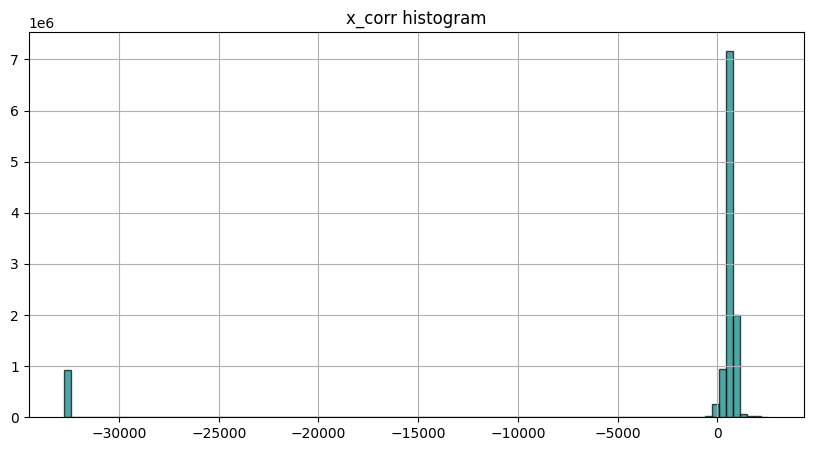

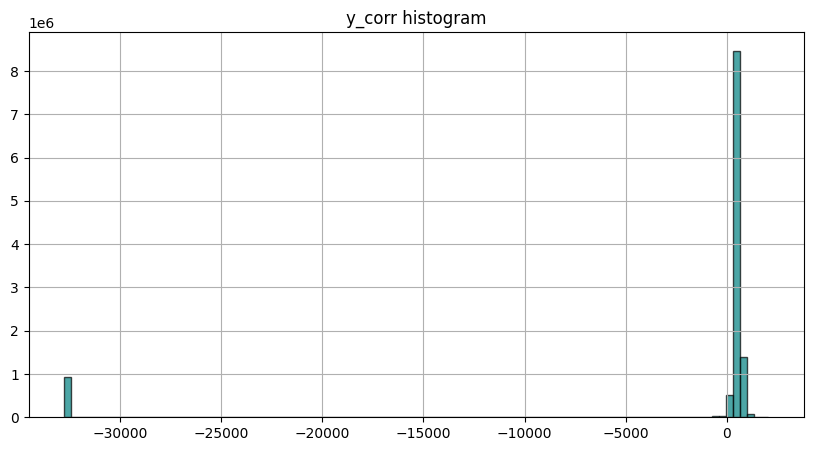

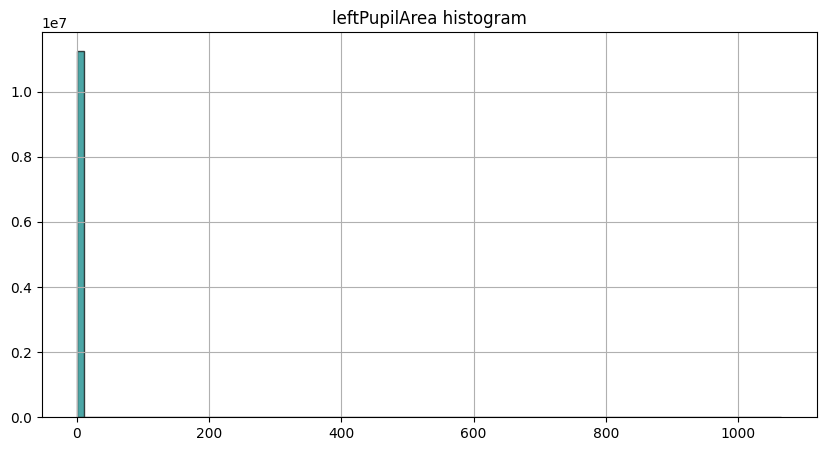

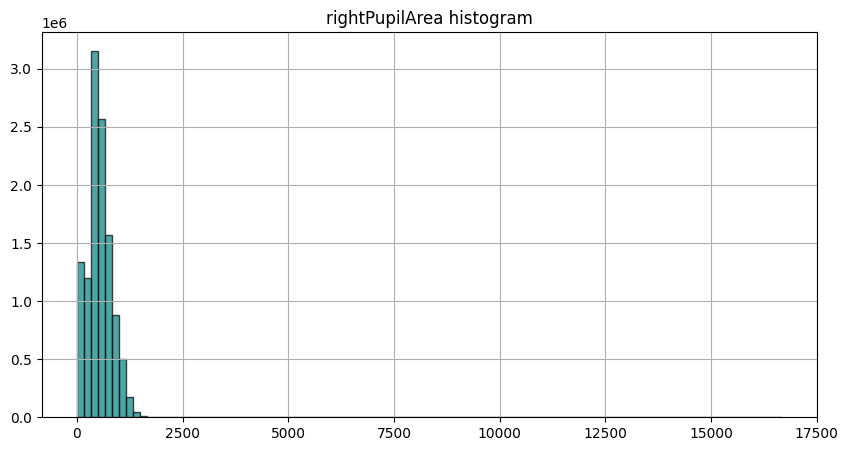

In [7]:
descr_stats(present_df2, 'rightEyeX')
descr_stats(present_df2, 'rightEyeY')
descr_stats(present_df2, 'leftPupilArea')
descr_stats(present_df2, 'rightPupilArea')

# check missing values 
print("missing values x_corr:", present_df2['rightEyeX'].isna().sum()) 
print("missing values y_corr:", present_df2['rightEyeY'].isna().sum())
print("missing values left_eye_pupil:", present_df2['leftPupilArea'].isna().sum())
print("missing values right_eye_pupil:", present_df2['rightPupilArea'].isna().sum())

# plot histograms 
plt.figure(figsize=(10, 5))
present_df2["rightEyeX"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
present_df2["rightEyeY"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

plt.figure(figsize=(10, 5))
present_df2["leftPupilArea"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("leftPupilArea histogram")

plt.figure(figsize=(10, 5))
present_df2["rightPupilArea"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("rightPupilArea histogram")

### 1. Clean Data: clip to screen dimension for x_corr and y_corr and recode extreme values of pupil diameter to 0 


#### 1a: Clip x_corr and y_corr to the screen dimensions 
Values outside the dimension of our screen get recoded to their the lower or upper bound

Summary stats for column: rightEyeX
mean     600.115032
min        0.000000
max     1920.000000
std      272.763015
Name: rightEyeX, dtype: float64
Summary stats for column: rightEyeY
mean     468.647492
min        0.000000
max     1080.000000
std      205.853143
Name: rightEyeY, dtype: float64


Text(0.5, 1.0, 'y_corr histogram')

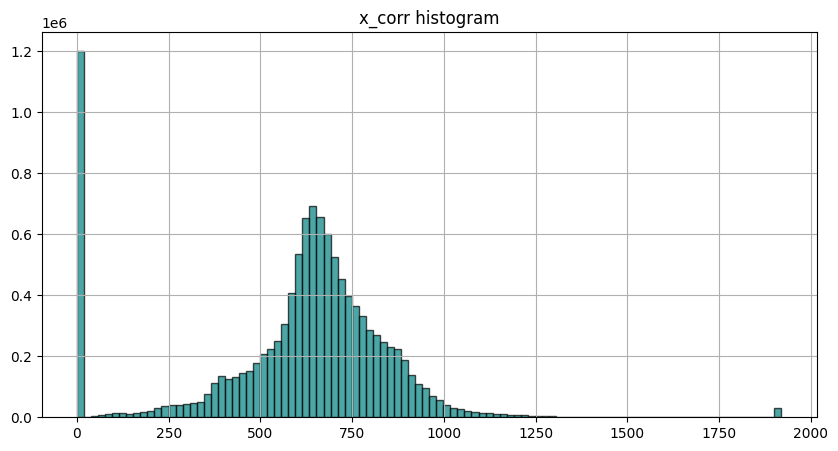

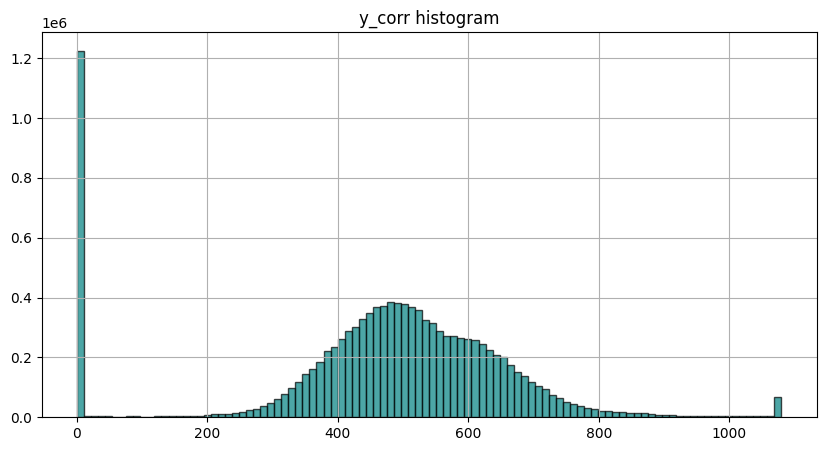

In [9]:
present_df2_filtered = present_df2.copy()

SCREEN_W = 1920
SCREEN_H = 1080

present_df2_filtered["rightEyeX"] = present_df2["rightEyeX"].clip(0, SCREEN_W)
present_df2_filtered["rightEyeY"] = present_df2["rightEyeY"].clip(0, SCREEN_H)

# Look at data again 
descr_stats(present_df2_filtered, 'rightEyeX')
descr_stats(present_df2_filtered, 'rightEyeY')

# plot histograms 
plt.figure(figsize=(10, 5))
present_df2_filtered["rightEyeX"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
present_df2_filtered["rightEyeY"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

#### 1b: Recode extreme values of pupil diameter to 0
To run the blink detection algothrim, it needs 0 values, not NA. 

In [10]:
print(present_df2.columns)

Index(['rightEyeX', 'rightEyeY', 'times', 'subjectID', 'leftPupilArea',
       'rightPupilArea'],
      dtype='object')


In [ ]:
# largest possible pupil value 
max_pupil_diameter = 9

# filter out data 
present_df2_filtered['left_eye_pupil_mm'] = present_df2_filtered["left_eye_pupil_mm"].where(
    present_df2_filtered['left_eye_pupil_mm'] <= max_pupil_diameter, 0
)
present_df2_filtered['right_eye_pupil_mm'] = present_df2_filtered["right_eye_pupil_mm"].where(
    present_df2_filtered['right_eye_pupil_mm'] <= max_pupil_diameter, 0
)

# re-check data 
descr_stats(present_df2_filtered, 'left_eye_pupil_mm')
descr_stats(present_df2_filtered, 'right_eye_pupil_mm')
plt.figure(figsize=(10, 5))
present_df2_filtered["left_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("left_eye_pupil_mm histogram")

plt.figure(figsize=(10, 5))
present_df2_filtered["right_eye_pupil_mm"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("right_eye_pupil_mm histogram")

### 2. Blink Detection - Hershman et al. 2018
Using open source code from Hershman et al. 2018: https://osf.io/jyz43/files/qh5sg

In [11]:
def diff(series):
	"""
	Python implementation of matlab's diff function
	"""
	return series[1:] - series[:-1]

def smooth(x, window_len):
	"""
	Python implementation of matlab's smooth function
	"""

	if window_len < 3:
		return x

	# Window length must be odd
	if window_len%2 == 0:
		window_len += 1

	w = np.ones(window_len)
	y = np.convolve(w, x, mode='valid') / len(w)
	y = np.hstack((x[:window_len//2], y, x[len(x)-window_len//2:]))

	for i in range(0, window_len//2):
		y[i] = np.sum(y[0 : i+i]) / ((2*i) + 1)

	for i in range(len(x)-window_len//2, len(x)):
		y[i] = np.sum(y[i - (len(x) - i - 1) : i + (len(x) - i - 1)]) / ((2*(len(x) - i - 1)) + 1)

	return y

def based_noise_blinks_detection(pupil_size, sampling_freq):
	"""
	Function to find blinks and return blink onset and offset indices
	Adapted from: R. Hershman, A. Henik, and N. Cohen, “A novel blink detection method based on pupillometry noise,” Behav. Res. Methods, vol. 50, no. 1, pp. 107–114, 2018.

	Input:
		pupil_size          : [numpy array/list] of pupil size data for left/right eye
		sampling_freq       : [float] sampling frequency of eye tracking hardware (default = 1000 Hz)
		concat              : [boolean] concatenate close blinks/missing trials or not. See R. Hershman et. al. for more information
		concat_gap_interval : [float] interval between successive missing samples/blinks to concatenate
	Output:
		blinks              : [dictionary] {"blink_onset", "blink_offset"} containing numpy array/list of blink onset and offset indices
	"""
	sampling_interval = 1000 // sampling_freq
	concat_gap_interval = 100

	blink_onset = []
	blink_offset = []
	blinks = {"blink_onset": blink_onset, "blink_offset": blink_offset}

	pupil_size = np.asarray(pupil_size)
	missing_data = np.array(pupil_size == 0, dtype="float32")
	difference = diff(missing_data)

	blink_onset = np.where(difference == 1)[0]
	blink_offset = np.where(difference == -1)[0] + 1

	length_blinks = len(blink_offset) + len(blink_onset)


	# Edge Case 1: there are no blinks
	if (length_blinks == 0):
		return blinks


	# Edge Case 2: the data starts with a blink. In this case, blink onset will be defined as the first missing value.
	"""
		Two possible situations may cause this:
			i.  starts with a blink but does not end with a blink ---> len(blink_onset) < len(blink_offset)
			ii. starts with a blink and ends with a blink		  ---> len(blink_onset) == len(blink_offset) and (blink_onset[0] == blink_offset[0])
	"""
	if ((len(blink_onset) < len(blink_offset)) or ((len(blink_onset) == len(blink_offset)) and (blink_onset[0] > blink_offset[0]))) and pupil_size[0] == 0:
		blink_onset = np.hstack((0, blink_onset))


	# Edge Case 3: the data ends with a blink. In this case, blink offset will be defined as the last missing sample
	"""
		Two possible situations may cause this:
			i.  ends with a blink but does not start with a blink ---> len(blink_offset) < len(blink_onset)
			ii. ends with a blink and starts with a blink		  ---> Already handled "start with blink" in Edge case 2 so it reduces to i (previous case)
	"""
	if (len(blink_offset) < len(blink_onset)) and pupil_size[-1] == 0:
		blink_offset = np.hstack((blink_offset, len(pupil_size) - 1))

	# Smoothing the data in order to increase the difference between the measurement noise and the eyelid signal.
	ms_4_smoothing = 10
	samples2smooth = ms_4_smoothing // sampling_interval
	smooth_pupil_size = np.array(smooth(pupil_size, samples2smooth), dtype='float32')

	smooth_pupil_size[np.where(smooth_pupil_size == 0)[0]] = float('nan')
	smooth_pupil_size_diff = diff(smooth_pupil_size)

	"""
	Finding values <=0 and >=0 in order to find monotonically increasing and decreasing sections of smoothened pupil data

			Eg. a =     [2, 1, 2, 8, 7, 6, 5, 4, 4, 0, 0, 0, 0, 0, 3, 3, 3, 8, 9, 10, 2, 3, 10]
	                              ----------------  S           E  =================
			diff(a)=   [-1  1  6 -1 -1 -1 -1  0 -4  0  0  0  0  3  0  0  5  1  1  -8  1  7]

	monotonically_dec = [T  F  F  T  T  T  T  T  T  T  T  T  T  F  T  T  F  F  F   T  F  F]   (T=True, F=False)
	monotonically_dec = [F  T  T  F  F  F  F  T  F  T  T  T  T  T  T  T  T  T  T   F  T  T]

	---> The monotonically decreasing sequence before the blink is underlined with -- and the monotonically increasing sequence after the blink with ==
	---> S : denotes the initially detected onset of blink
	---> E : denotes the initially detected offset of blink

	>> Looking at diff(a), all values in the montonically decreasing sequence should be <= 0 and those included in the monotonically increasing sequence >= 0
	>> Hence, by moving left from the initially detected onset while T(True) values are encountered in monotonically_dec we can update the onset to the start of monotonically_dec seq
	>> By moving right from the initially detected offset while T(True) values are encountered in monotonically_inc we can update the offset to the end of monotonically_inc seq + 1
	"""
	monotonically_dec = smooth_pupil_size_diff <= 0
	monotonically_inc = smooth_pupil_size_diff >= 0

	# Finding correct blink onsets and offsets using monotonically increasing and decreasing arrays
	for i in range(len(blink_onset)):
		# Edge Case 2: If data starts with blink we do not update it and let starting blink index be 0
		if blink_onset[i] != 0:
			j = blink_onset[i] - 1
			while j > 0 and monotonically_dec[j] == True:
				j -= 1
			blink_onset[i] = j + 1

		# Edge Case 3: If data ends with blink we do not update it and let ending blink index be the last index of the data
		if blink_offset[i] != len(pupil_size) - 1:
			j = blink_offset[i]
			while j < len(monotonically_inc) and monotonically_inc[j] == True:
				j += 1
			blink_offset[i] = j

	# Removing duplications (in case of consecutive sets): [a, b, b, c] => [a, c] or if inter blink interval is less than concat_gap_interval
	c = np.empty((len(blink_onset) + len(blink_offset),), dtype=blink_onset.dtype)
	c[0::2] = blink_onset
	c[1::2] = blink_offset
	c = list(c)

	i = 1
	while i<len(c)-1:
		if c[i+1] - c[i] <= concat_gap_interval:
			c[i:i+2] = []
		else:
			i += 2

	temp = np.reshape(c, (-1, 2), order='C')

	"""
	Multplied by sampling interval in order to give onset and offset in real time (milliseconds) by factoring in sampling rate of device used
	'+ sampling_interval' because the output should be in real time and as python indexing starts at 0 instead of 1, this is the standardising factor
	NOTE:edit the lines below to only temp[:, 0] and temp[:, 1] in case you are interested in the indices of blinks and not realtime values
	"""
	blinks["blink_onset"] = (temp[:, 0] * sampling_interval) + sampling_interval
	blinks["blink_offset"] = (temp[:, 1] * sampling_interval) + sampling_interval

	return blinks

Confirm sampling rate 

In [12]:
# Calculate time difference between consecutive samples 
present_df2_filtered['time_diff'] = present_df2_filtered.groupby('subjectID')['times'].diff()

# Calculate sampling rate (Hz)
present_df2_filtered['sampling_rate'] = 1 / present_df2_filtered['time_diff']

descr_stats(present_df2_filtered, 'sampling_rate')

Summary stats for column: sampling_rate
mean       512.649037
min          2.446807
max     127100.121671
std        326.829104
Name: sampling_rate, dtype: float64


mean       512.649037
min          2.446807
max     127100.121671
std        326.829104
Name: sampling_rate, dtype: float64

Detect blinks - make sure this works 

In [15]:
sampling_freq = 500
blinks = based_noise_blinks_detection(present_df2_filtered['rightPupilArea'], sampling_freq)
print(blinks)

{'blink_onset': array([     538,     1536,     4130, ..., 22931462, 22932602, 22934158],
      shape=(6453,)), 'blink_offset': array([     758,     1764,     4304, ..., 22931550, 22932938, 22934272],
      shape=(6453,))}


Mask blinks - function to run blink detection algothrim on whole sample 

In [16]:
BLINK_BUFFER_MS = 50  # buffer 50 ms before and after blink

def mask_blinks(df, sample_rate, buffer_ms=BLINK_BUFFER_MS):
    """
    Detect blinks using Hershman et al. (2018) and set gaze to NaN
    during blink periods + buffer window around each blink.
    Requires a pupil diameter column (0 = missing/blink).
    """
    df = df.sort_values(["subjectID", "times"]).reset_index(drop=True)

    print("column names:", df.columns)

    df[["rightEyeX", "rightEyeY"]] = (
        df[["rightEyeX", "rightEyeY"]].astype(float)
    )

    total_blinks = 0

    for subj, grp in df.groupby("subjectID"):

        idx = grp.index

        # Algorithm expects missing pupil values to be 0
        pupil = grp["rightPupilArea"].fillna(0).to_numpy().copy()
        pupil[pupil < 0] = 0

        # Detect blinks for THIS SUBJECT ONLY
        blinks = based_noise_blinks_detection(
            pupil,
            sampling_freq=sample_rate,
        )

        n_blinks = len(blinks["blink_onset"])
        total_blinks += n_blinks

        if n_blinks == 0:
            continue

        # Subject's timestamps (seconds -> milliseconds)
        times_ms = grp["times"].to_numpy() * 1000

        for onset_ms, offset_ms in zip(
            blinks["blink_onset"],
            blinks["blink_offset"],
        ):

            blink_mask = (
                (times_ms >= onset_ms - buffer_ms)
                & (times_ms <= offset_ms + buffer_ms)
            )

            df.loc[
                idx[blink_mask],
                ["rightEyeX", "rightEyeY"],
            ] = np.nan

    print(
        f"[Step 2] Total blinks detected: {total_blinks} across "
        f"{df['subjectID'].nunique()} subjects"
    )

    print(
        f"         NaN gaze samples after masking: "
        f"{df['rightEyeX'].isna().sum()} "
        f"({df['rightEyeX'].isna().mean() * 100:.2f}%)"
    )

    return df

Apply blink detection 

In [17]:
# Make a copy of the dataframe 
present_df2_mask = present_df2_filtered.copy()

# Apply blink detection filter 
present_df2_mask = mask_blinks(present_df2_mask, sample_rate=500)

column names: Index(['rightEyeX', 'rightEyeY', 'times', 'subjectID', 'leftPupilArea',
       'rightPupilArea', 'time_diff', 'sampling_rate'],
      dtype='object')
[Step 2] Total blinks detected: 6458 across 105 subjects
         NaN gaze samples after masking: 1583406 (13.81%)


Re-plot data to see what it looks like

Text(0.5, 1.0, 'rightPupilArea histogram')

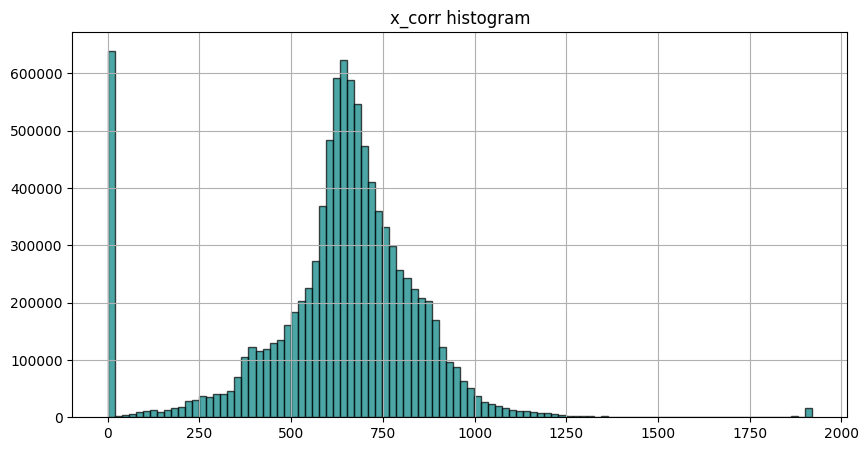

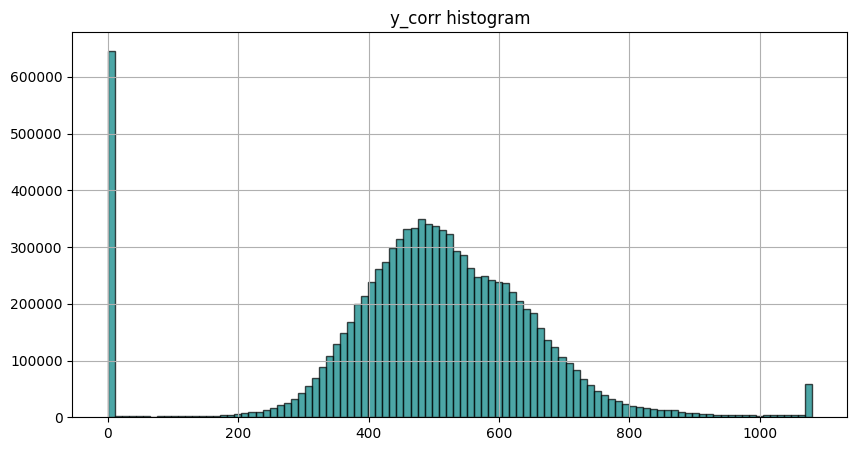

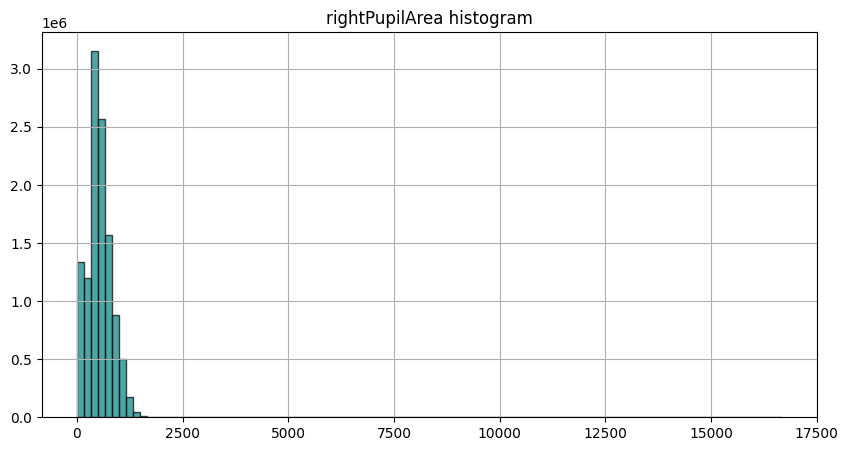

In [18]:
# plot histograms 
plt.figure(figsize=(10, 5))
present_df2_mask["rightEyeX"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr histogram")

plt.figure(figsize=(10, 5))
present_df2_mask["rightEyeY"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr histogram")

plt.figure(figsize=(10, 5))
present_df2_mask["rightPupilArea"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("rightPupilArea histogram")

### 3. Butterworth Low Pass Filter

In [19]:
# documentation: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.butter.html
sampling_rate = 500
cutoff_freq = 50
filter_order = 2    

def butter_lowpass_filter(data, cutoff, fs, order=2):
    nyq = 0.5 * fs # Nyquist frequency; recommended from documentation 
    normal_cutoff = cutoff / nyq
    # Get the filter coefficients
    #   Using order 2, nyquist freq, lowpass filter, and for digital signal
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    # Apply filter forwards and backwards to eliminate phase distortion
    y = filtfilt(b, a, data)
    return y

# Make copy of dataframe 
present_df2_butter = present_df2_mask.copy()

# Apply the low pass filter
present_df2_butter['rightEyeX_butter'] = butter_lowpass_filter(present_df2_butter['rightEyeX'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)
present_df2_butter['rightEyeY_butter'] = butter_lowpass_filter(present_df2_butter['rightEyeY'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)

/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_4782/648857126.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  present_df2_butter['rightEyeX_butter'] = butter_lowpass_filter(present_df2_butter['rightEyeX'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)
/var/folders/xq/f83j3jh14fz6j650prgjddldpxs0f4/T/ipykernel_4782/648857126.py:21: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  present_df2_butter['rightEyeY_butter'] = butter_lowpass_filter(present_df2_butter['rightEyeY'].fillna(method='ffill').values, cutoff_freq, sampling_rate, filter_order)


Re-plot to see what data looks like

Text(0.5, 1.0, 'y_corr_butter histogram')

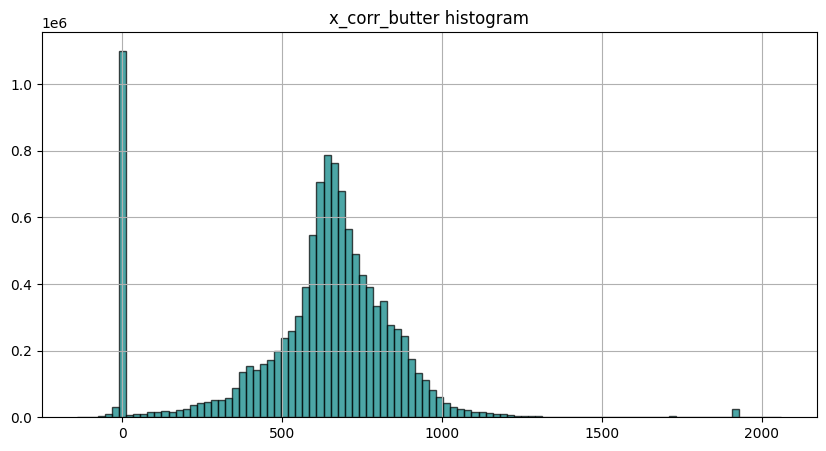

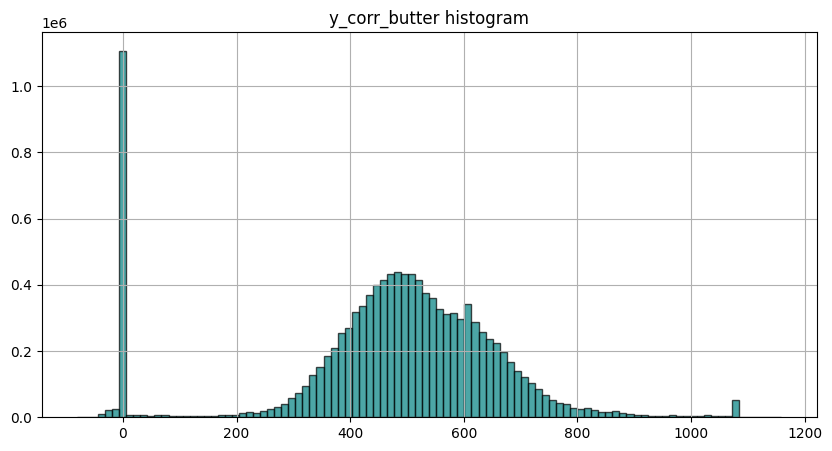

In [20]:
# plot histograms 
plt.figure(figsize=(10, 5))
present_df2_butter["rightEyeX_butter"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("x_corr_butter histogram")

plt.figure(figsize=(10, 5))
present_df2_butter["rightEyeY_butter"].hist(
    bins=100, color="teal", edgecolor="black", alpha=0.7
)
plt.title("y_corr_butter histogram")

Show filtered vs. unfiltered data 

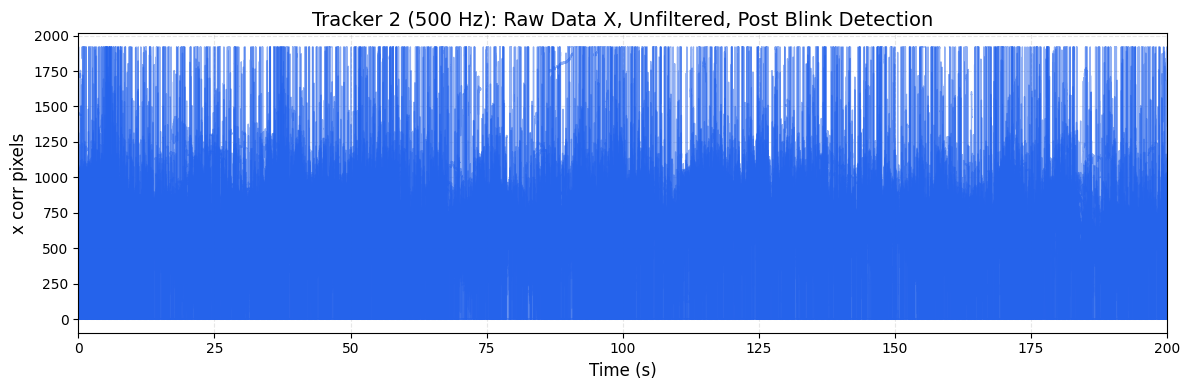

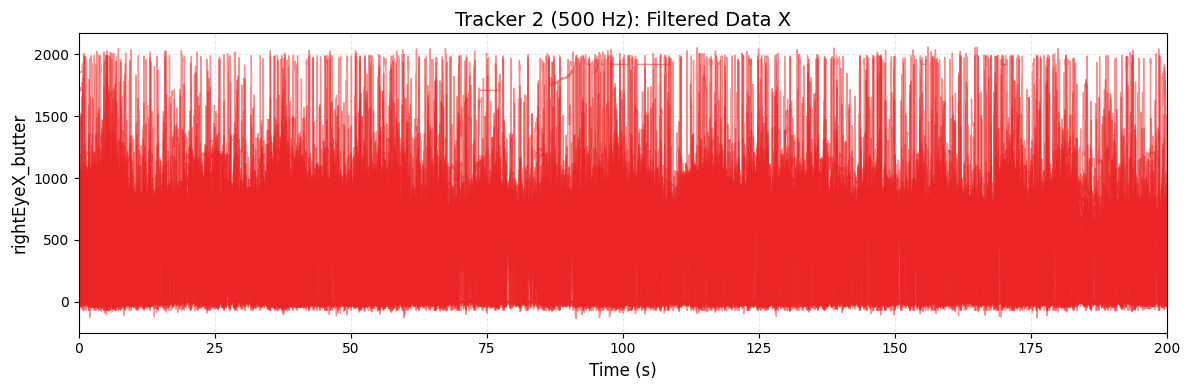

In [22]:
############ x
########### UNFILTERED, POST BLINK

fig, ax = plt.subplots(figsize=(12, 4))

for subject, df in present_df2_mask.groupby("subjectID"):
    df = df.sort_values("times")
    ax.plot(
        df["times"],
        df["rightEyeX"],
        linewidth=1,
        color="#2563eb",
        alpha=0.5,
    )

ax.set_xlim(0, 200)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("x corr pixels", fontsize=12)
ax.set_title("Tracker 2 (500 Hz): Raw Data X, Unfiltered, Post Blink Detection", fontsize=14)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()


############ FILTERED

fig, ax = plt.subplots(figsize=(12, 4))

for subject, df in present_df2_butter.groupby("subjectID"):
    df = df.sort_values("times")
    ax.plot(
        df["times"],
        df["rightEyeX_butter"],
        linewidth=1,
        color="#eb2525",
        alpha=0.5,
    )

ax.set_xlim(0, 200)

ax.set_xlabel("Time (s)", fontsize=12)
ax.set_ylabel("rightEyeX_butter", fontsize=12)
ax.set_title("Tracker 2 (500 Hz): Filtered Data X", fontsize=14)
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

Get subset of subjects to plot 


In [23]:
subset_subjects = present_df2_mask['subjectID'].unique()[0:5]
print(subset_subjects)


present_df2_mask_subset = present_df2_mask[present_df2_mask['subjectID'].isin(subset_subjects)]
print("length of present_df2_mask:", len(present_df2_mask))
print("length of present_df2_mask_subset:", len(present_df2_mask_subset))

present_df2_butter_subset = present_df2_butter[present_df2_butter['subjectID'].isin(subset_subjects)]
print("length of present_df2_butter:", len(present_df2_butter))
print("length of present_df2_butter_subset:", len(present_df2_butter_subset))

['sub-A00008326' 'sub-A00014880' 'sub-A00015238' 'sub-A00018181'
 'sub-A00024751']
length of present_df2_mask: 11467271
length of present_df2_mask_subset: 629337
length of present_df2_butter: 11467271
length of present_df2_butter_subset: 629337


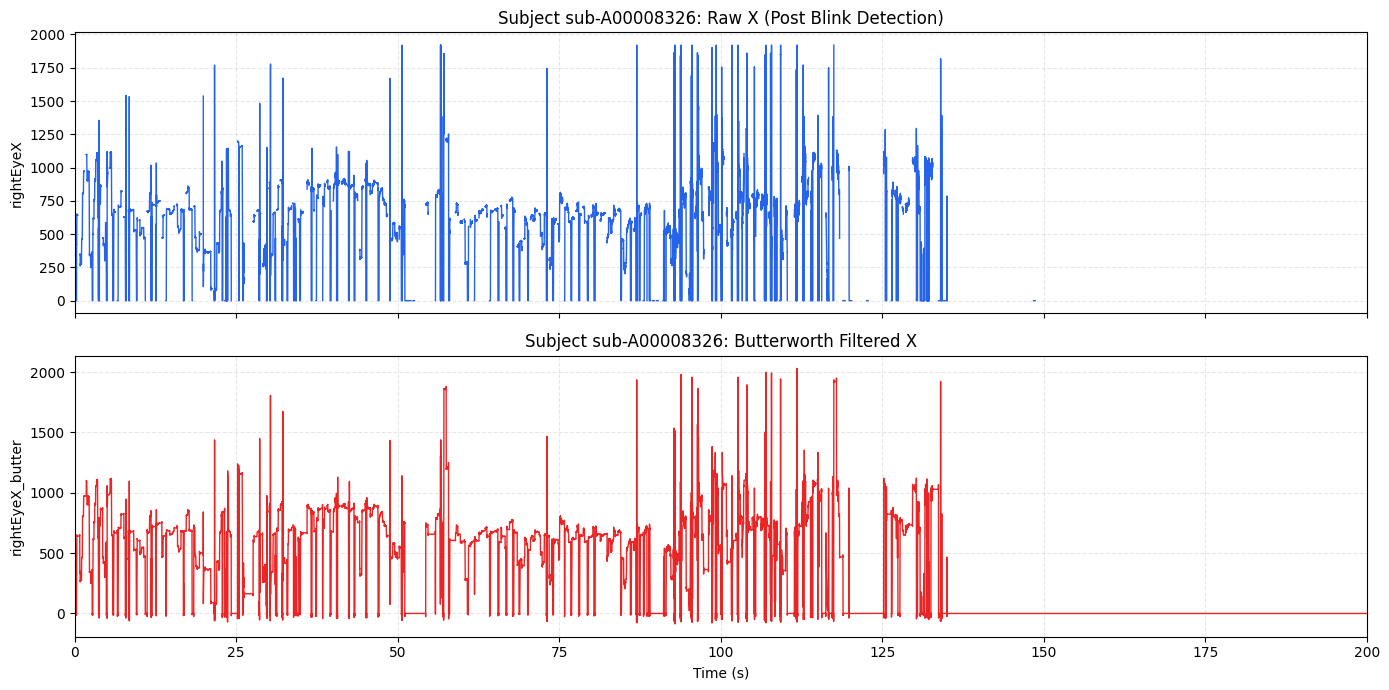

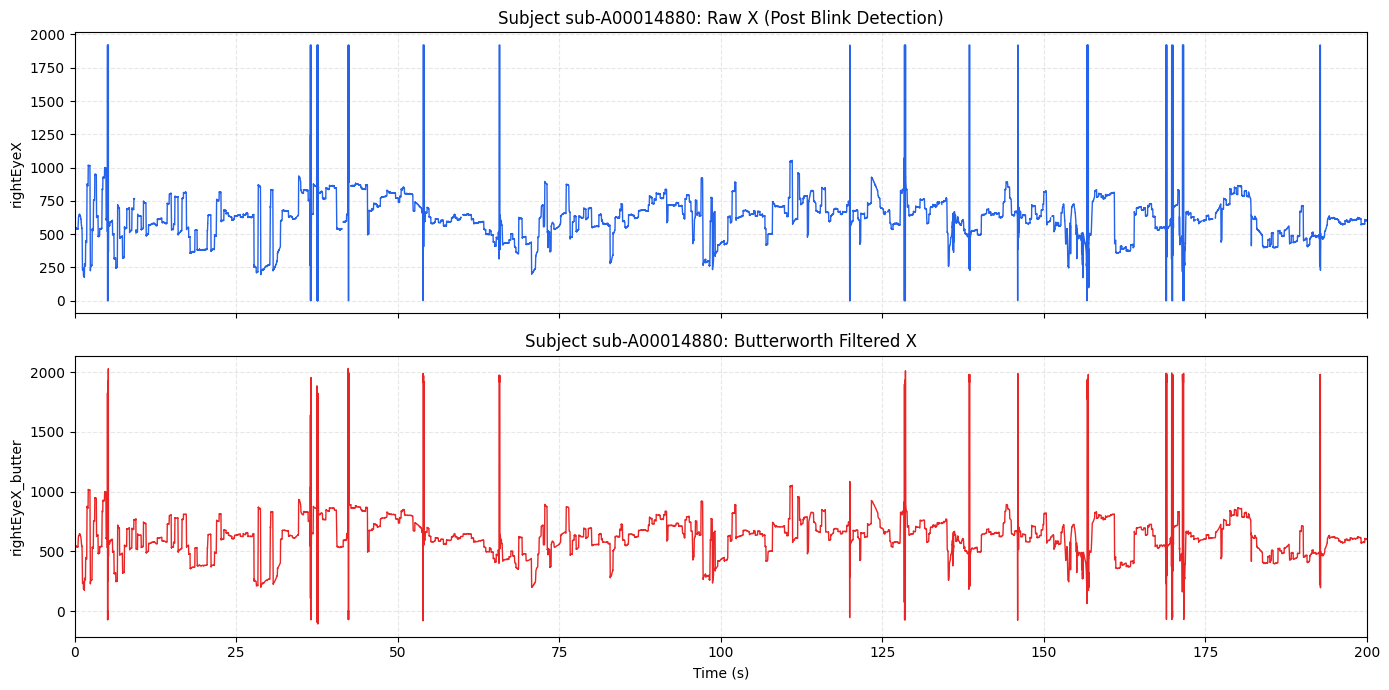

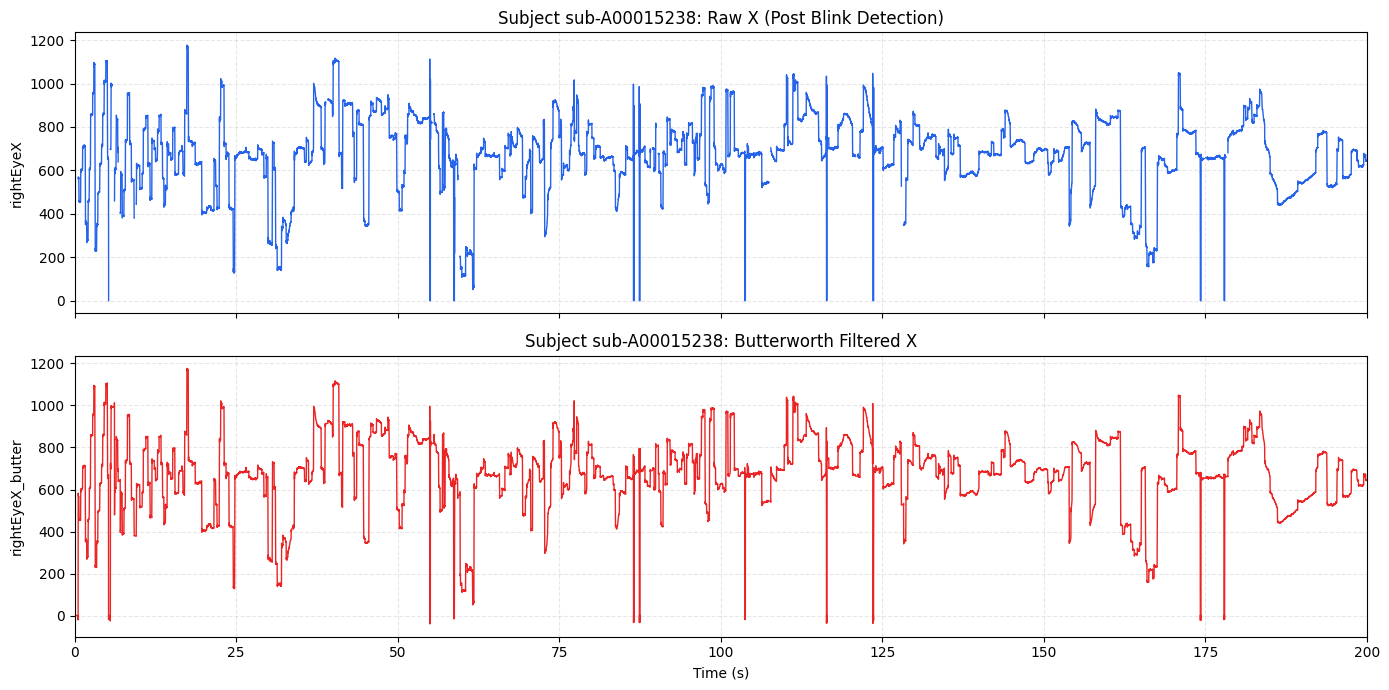

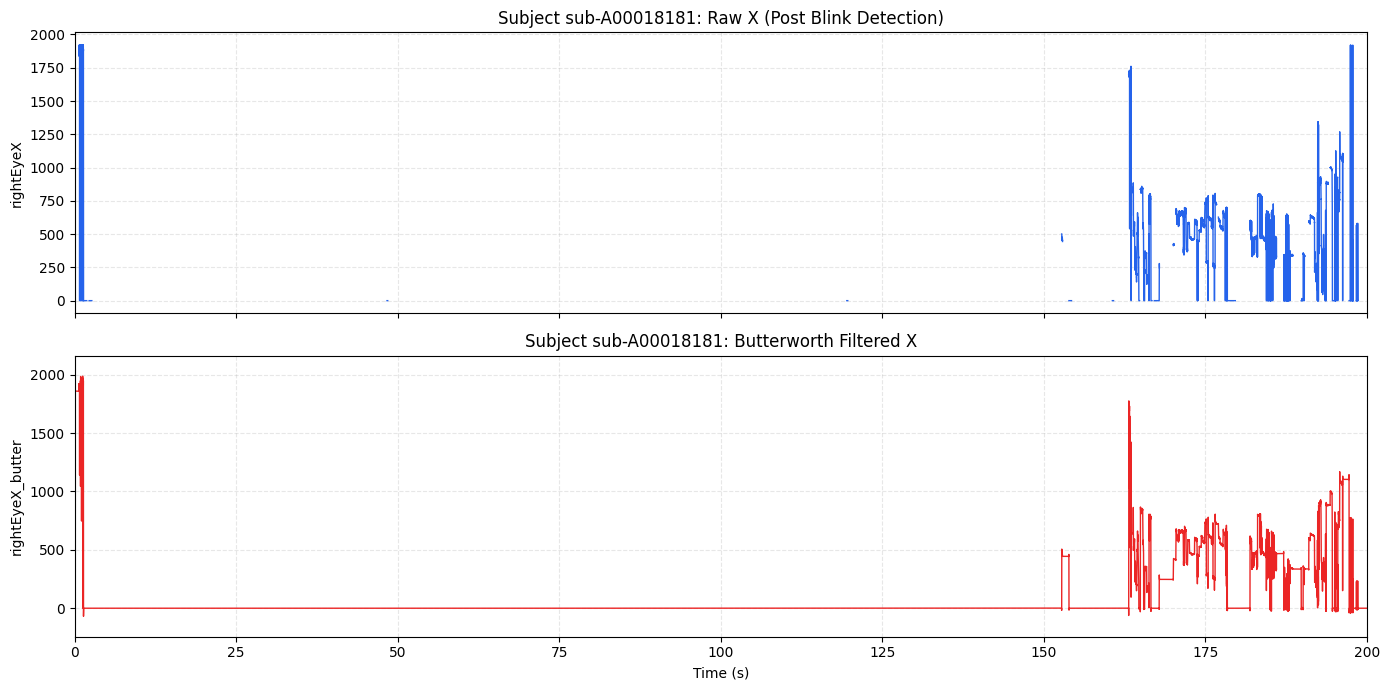

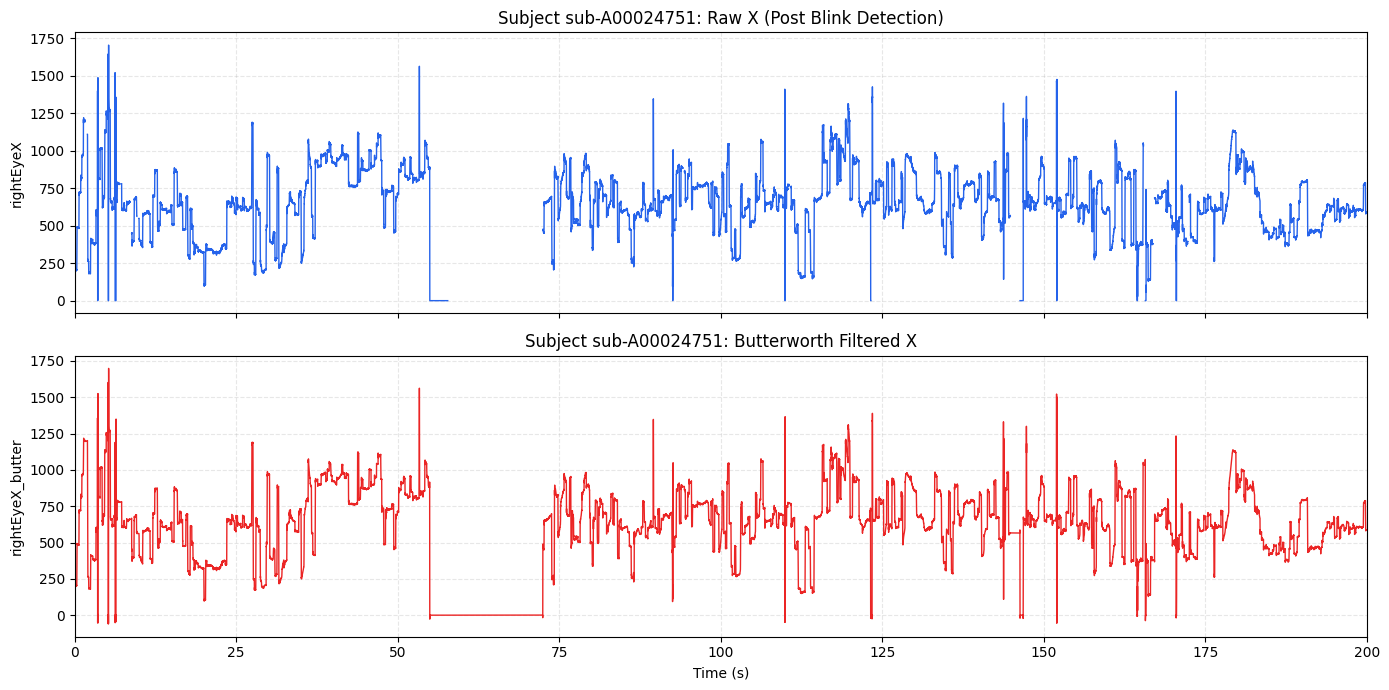

In [26]:
subjects = sorted(present_df2_mask_subset["subjectID"].unique())

for subject in subjects:
    raw = present_df2_mask_subset[
        present_df2_mask_subset["subjectID"] == subject
    ]
    filt = present_df2_butter_subset[
        present_df2_butter_subset["subjectID"] == subject
    ]

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    # Raw
    axes[0].plot(
        raw["times"],
        raw["rightEyeX"],
        color="#2563eb",
        linewidth=1,
    )
    axes[0].set_xlim(0,200)
    axes[0].set_title(f"Subject {subject}: Raw X (Post Blink Detection)")
    axes[0].set_ylabel("rightEyeX")
    axes[0].grid(alpha=0.3, linestyle="--")

    # Filtered
    axes[1].plot(
        filt["times"],
        filt["rightEyeX_butter"],
        color="#eb2525",
        linewidth=1,
    )
    axes[1].set_xlim(0,200)
    axes[1].set_title(f"Subject {subject}: Butterworth Filtered X")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("rightEyeX_butter")
    axes[1].grid(alpha=0.3, linestyle="--")

    plt.tight_layout()
    plt.show()

### 4. Standarized Data (min-max filter)

In [27]:
# Make copy of dataframe 
present_df2_norm = present_df2_butter.copy()

# rightEyeX_butter 
x_min_present_ds1 = present_df2_norm['rightEyeX_butter'].min()
x_max_present_ds1 = present_df2_norm['rightEyeX_butter'].max()
present_df2_norm['x_norm'] = (present_df2_norm['rightEyeX_butter'] - x_min_present_ds1) / (x_max_present_ds1 - x_min_present_ds1)
descr_stats(present_df2_norm, 'x_norm')

# rightEyeY_butter 
y_min_present_ds1 = present_df2_norm['rightEyeY_butter'].min()
y_max_present_ds1 = present_df2_norm['rightEyeY_butter'].max()
present_df2_norm['y_norm'] = (present_df2_norm['rightEyeY_butter'] - y_min_present_ds1) / (y_max_present_ds1 - y_min_present_ds1)
descr_stats(present_df2_norm, 'y_norm')

Summary stats for column: x_norm
mean    0.337373
min     0.000000
max     1.000000
std     0.122666
Name: x_norm, dtype: float64
Summary stats for column: y_norm
mean    0.444216
min     0.000000
max     1.000000
std     0.163977
Name: y_norm, dtype: float64


mean    0.444216
min     0.000000
max     1.000000
std     0.163977
Name: y_norm, dtype: float64

### 5. Computer Euclidean Distance

In [28]:
# Sort data by time per subject (to get time diference)
present_df2_norm = present_df2_norm.sort_values(by=["subjectID", "times"]).reset_index(drop=True)

# Calculate the difference (x2 - x1) and (y2 - y1) per subject 
present_df2_norm["diff_x"] = present_df2_norm.groupby("subjectID")["x_norm"].diff()
present_df2_norm["diff_y"] = present_df2_norm.groupby("subjectID")["y_norm"].diff()

# Calculate Eucledian Distance: z = sqrt((x2-x1)^2 + (y2-y1)^2)
present_df2_norm["z_eucledian_dist"] = np.sqrt(present_df2_norm["diff_x"] ** 2 + present_df2_norm['diff_y'] ** 2)

# Check Eucledian Distance 
print(descr_stats(present_df2_norm, 'z_eucledian_dist'))

Summary stats for column: z_eucledian_dist
mean    0.002281
min     0.000000
max     0.287885
std     0.011795
Name: z_eucledian_dist, dtype: float64
mean    0.002281
min     0.000000
max     0.287885
std     0.011795
Name: z_eucledian_dist, dtype: float64


In [29]:
#### Current number of samples
print("Current number of samples:", len(present_df2_norm))

# Filter out extreme values of Eucledian Distance 
z_eucledian_dist_mean = present_df2_norm['z_eucledian_dist'].mean()
z_eucledian_dist_std = present_df2_norm['z_eucledian_dist'].std()
upper_z_eucled = z_eucledian_dist_mean + (2.5*z_eucledian_dist_std)
lower_z_eucled = z_eucledian_dist_mean - (2.5*z_eucledian_dist_std)
print(upper_z_eucled)
print("Z EUCLEDIAN DISTANCE BEFORE")
print(f"mean: {z_eucledian_dist_mean}; min: {present_df2_norm['z_eucledian_dist'].min()}; max: {present_df2_norm['z_eucledian_dist'].max()}") 

# filter 
present_df2_norm = present_df2_norm[present_df2_norm['z_eucledian_dist'] >= lower_z_eucled]
present_df2_norm = present_df2_norm[present_df2_norm['z_eucledian_dist'] <= upper_z_eucled]

print("*"*50)
print("Z EUCLEDIAN DISTANCE after filter")
print(f"mean: {present_df2_norm['z_eucledian_dist'].mean()}; min: {present_df2_norm['z_eucledian_dist'].min()}; max: {present_df2_norm['z_eucledian_dist'].max()}")
print("New samples:", len(present_df2_norm))


Current number of samples: 11467271
0.03176963661851663
Z EUCLEDIAN DISTANCE BEFORE
mean: 0.0022811132364456005; min: 0.0; max: 0.28788546876440213
**************************************************
Z EUCLEDIAN DISTANCE after filter
mean: 0.0011049012719586485; min: 0.0; max: 0.03176915861446362
New samples: 11308910


### 6. Compute ISC 


In [31]:
df = present_df2_norm.copy()

# --- Interpolate onto time grid (same as before) ---
time_grid = np.linspace(df['times'].min(), df['times'].max(), 500)
subjects = df['subjectID'].unique()

x_mat, y_mat = [], []
for subj in subjects:
    d = df[df['subjectID'] == subj].sort_values('times')
    x_mat.append(np.interp(time_grid, d['times'], d['rightEyeX_butter']))
    y_mat.append(np.interp(time_grid, d['times'], d['rightEyeY_butter']))

x_mat = np.array(x_mat)  # shape: (n_subjects, n_timepoints)
y_mat = np.array(y_mat)

n = len(subjects)

# --- Vectorized LOO mean ---
# Instead of recomputing mean of 299 subjects each time,
# subtract current subject from grand sum and divide by (n-1)
x_sum = x_mat.sum(axis=0)
y_sum = y_mat.sum(axis=0)

isc_results = []
for i, subj in enumerate(subjects):
    x_loo_mean = (x_sum - x_mat[i]) / (n - 1)
    y_loo_mean = (y_sum - y_mat[i]) / (n - 1)

    isc_x, _ = pearsonr(x_mat[i], x_loo_mean)
    isc_y, _ = pearsonr(y_mat[i], y_loo_mean)

    isc_results.append({
        "subjectID": subj,
        "ISC_x": isc_x,
        "ISC_y": isc_y,
        "ISC_mean": np.nanmean([isc_x, isc_y])
    })

isc_ds2_present = pd.DataFrame(isc_results)
isc_ds2_present['rank_x'] = isc_ds2_present['ISC_x'].rank()
isc_ds2_present['rank_y'] = isc_ds2_present['ISC_y'].rank()
isc_ds2_present['rank_mean'] = isc_ds2_present['ISC_mean'].rank()
print(isc_ds2_present.head())
os.system('afplay "/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/library/beepr/sounds/smb_stage_clear.wav"')

       subjectID     ISC_x     ISC_y  ISC_mean  rank_x  rank_y  rank_mean
0  sub-A00008326  0.322228 -0.110301  0.105964    46.0    10.0       18.0
1  sub-A00014880  0.585897  0.209076  0.397487    96.0    54.0       76.0
2  sub-A00015238  0.414077  0.053041  0.233559    59.0    24.0       43.0
3  sub-A00018181 -0.353641 -0.046652 -0.200146     3.0    15.0        2.0
4  sub-A00024751  0.518109  0.180131  0.349120    83.0    43.0       68.0


0

Combine ISC data with dataframe 


In [32]:
df = present_df2_norm.merge(isc_ds2_present[['subjectID', 'ISC_mean', "rank_mean"]], on="subjectID")
print(df.head())

    rightEyeX   rightEyeY     times      subjectID  leftPupilArea  \
0  629.700012  519.400024 -1.365070  sub-A00008326            0.0   
1  629.700012  519.400024 -1.363065  sub-A00008326            0.0   
2  627.400024  524.000000 -1.361112  sub-A00008326            0.0   
3  623.799988  529.200012 -1.359141  sub-A00008326            0.0   
4  623.799988  529.200012 -1.357196  sub-A00008326            0.0   

   rightPupilArea  time_diff  sampling_rate  rightEyeX_butter  \
0           317.0   0.002108     474.415111        628.507191   
1           312.0   0.002005     498.787490        627.691102   
2           309.0   0.001953     511.937508        626.595351   
3           307.0   0.001971     507.416405        625.370118   
4           307.0   0.001945     514.133856        624.247271   

   rightEyeY_butter    x_norm    y_norm    diff_x    diff_y  z_eucledian_dist  \
0        520.367642  0.349498  0.484887 -0.000269  0.001427          0.001452   
1        522.436491  0.349127  0

### 7. PLOT

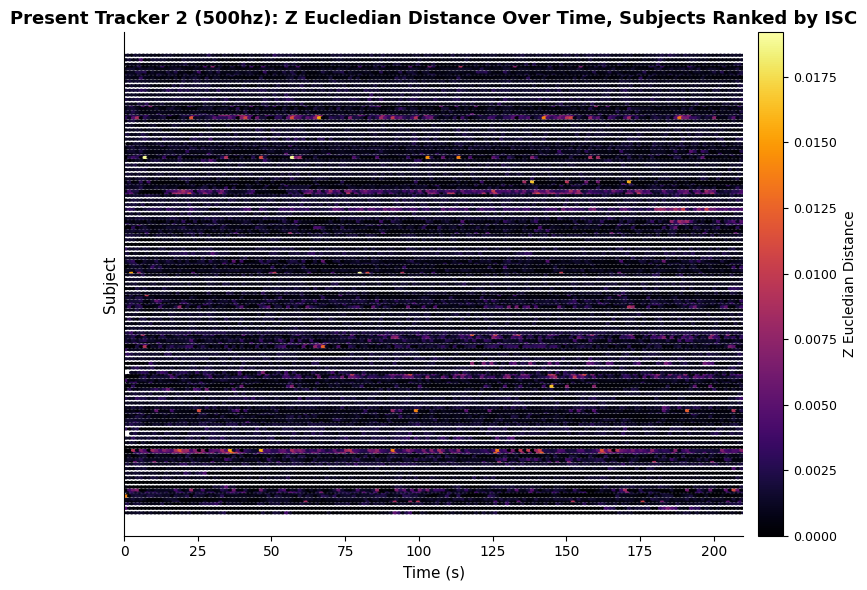

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

# Replace KDE loop with hexbin — fully vectorized, runs in seconds
hb = ax.hexbin(
    df["times"],
    df["rank_mean"],
    C=df["z_eucledian_dist"],          # color = mean x_norm in each hex cell
    gridsize=(300, 150),     # (x_bins, y_bins) — adjust for resolution
    cmap="inferno",
    reduce_C_function=np.mean,
    rasterized=True
)

cbar = fig.colorbar(hb, ax=ax, pad=0.02)
cbar.set_label("Z Eucledian Distance", fontsize=10)
cbar.ax.tick_params(labelsize=9)

# # Y-axis: show ISC score values instead of rank integers
# n_ticks = 8
# # tick_ranks = np.linspace(0, df["rank_y"].max(), n_ticks, dtype=int)
# tick_ranks = np.linspace(df["rank_y"].min(),
#                          df["rank_y"].max(),
#                          n_ticks,
#                          dtype=int)
# tick_labels = [f"{isc_df_sherlock.loc[isc_df_sherlock['rank_y'] == r, 'ISC_y'].values[0]:.2f}" for r in tick_ranks]
# ax.set_yticks(tick_ranks)
# ax.set_yticklabels(tick_labels, fontsize=9)
ax.set_yticks([])

# Set x-axis 
plt.xlim(0,210)

ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Subject", fontsize=11)
ax.set_title("Present Tracker 2 (500hz): Z Eucledian Distance Over Time, Subjects Ranked by ISC", fontsize=13, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()